In [4]:
import numpy as np
import torch
import os
import logging
import yaml
import pandas as pd
import sys
import matplotlib.pyplot as plt
import glob
import awkward as ak
import pandas as pd
import joblib  # For saving the scaler
from sklearn.model_selection import train_test_split

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier
from SimpleMAF import SimpleMAF

mc_path = "/home/aegis/Titan1/NRAD/data/Regions"
data_path = "/home/aegis/Titan1/NRAD/data/Regions_data"

### MC and Data Events

In [74]:
MC_CR_emu_path = glob.glob(os.path.join(mc_path, f"CR_emu", "*.parquet"))
MC_CR0L_path = glob.glob(os.path.join(mc_path, "CR0L_Inclusive", "*.parquet"))
MC_CR1ele_path = glob.glob(os.path.join(mc_path, "CR1ele", "*.parquet"))
MC_CR1eleb_path = glob.glob(os.path.join(mc_path, "CR1eleb", "*.parquet"))
MC_CR1mu_path = glob.glob(os.path.join(mc_path, "CR1mu", "*.parquet"))
MC_CR1mub_path = glob.glob(os.path.join(mc_path, "CR1mub", "*.parquet"))
MC_CR2ele_path = glob.glob(os.path.join(mc_path, "CR2ele", "*.parquet"))
MC_CR2mu_path = glob.glob(os.path.join(mc_path, "CR2mu", "*.parquet"))

print("CR_emu files:", len(MC_CR_emu_path))
print("CR0L files:", len(MC_CR0L_path))
print("CR1ele files:", len(MC_CR1ele_path))
print("CR1eleb files:", len(MC_CR1eleb_path))
print("CR1mu files:", len(MC_CR1mu_path))
print("CR1mub files:", len(MC_CR1mub_path))
print("CR2ele files:", len(MC_CR2ele_path))
print("CR2mu files:", len(MC_CR2mu_path))

Data_CR_emu_path = glob.glob(os.path.join(data_path, "CR_emu", "*.parquet"))
Data_CR0L_path = glob.glob(os.path.join(data_path, "CR0L_Inclusive", "*.parquet"))
Data_CR1ele_path = glob.glob(os.path.join(data_path, "CR1ele", "*.parquet"))
Data_CR1eleb_path = glob.glob(os.path.join(data_path, "CR1eleb", "*.parquet"))
Data_CR1mu_path = glob.glob(os.path.join(data_path, "CR1mu", "*.parquet"))
Data_CR1mub_path = glob.glob(os.path.join(data_path, "CR1mub", "*.parquet"))
Data_CR2ele_path = glob.glob(os.path.join(data_path, "CR2ele", "*.parquet"))
Data_CR2mu_path = glob.glob(os.path.join(data_path, "CR2mu", "*.parquet"))

print("CR_emu data files:", len(Data_CR_emu_path))
print("CR0L data files:", len(Data_CR0L_path))
print("CR1ele data files:", len(Data_CR1ele_path))
print("CR1eleb data files:", len(Data_CR1eleb_path))
print("CR1mu data files:", len(Data_CR1mu_path))
print("CR1mub data files:", len(Data_CR1mub_path))
print("CR2ele data files:", len(Data_CR2ele_path))
print("CR2mu data files:", len(Data_CR2mu_path))

CR_emu files: 4392
CR0L files: 5353
CR1ele files: 3799
CR1eleb files: 3065
CR1mu files: 5217
CR1mub files: 4697
CR2ele files: 1334
CR2mu files: 3895
CR_emu data files: 14257
CR0L data files: 44674
CR1ele data files: 28371
CR1eleb data files: 19694
CR1mu data files: 43015
CR1mub data files: 42311
CR2ele data files: 1081
CR2mu data files: 31628


In [75]:
SCALAR_VARS = ["met_recalc_pt", "met_recalc_phi", "weight_phys"]
VECTOR_VARS = ["AnalysisJetsAuxDyn_pt", "AnalysisJetsAuxDyn_eta", "AnalysisJetsAuxDyn_phi", 
               "AnalysisLargeRJetsAuxDyn_pt", "AnalysisLargeRJetsAuxDyn_eta", "AnalysisLargeRJetsAuxDyn_phi",
               "AnalysisLargeRJetsAuxDyn_Tau1_wta", "AnalysisLargeRJetsAuxDyn_Tau2_wta", "AnalysisLargeRJetsAuxDyn_Tau3_wta", 
               ]

columns_to_load = SCALAR_VARS + VECTOR_VARS

MC_CR_emu_events = ak.from_parquet(MC_CR_emu_path, columns=columns_to_load)
MC_CR0L_events = ak.from_parquet(MC_CR0L_path, columns=columns_to_load)
MC_CR1ele_events = ak.from_parquet(MC_CR1ele_path, columns=columns_to_load)
MC_CR1eleb_events = ak.from_parquet(MC_CR1eleb_path, columns=columns_to_load)
MC_CR1mu_events = ak.from_parquet(MC_CR1mu_path, columns=columns_to_load)
MC_CR1mub_events = ak.from_parquet(MC_CR1mub_path, columns=columns_to_load)
MC_CR2ele_events = ak.from_parquet(MC_CR2ele_path, columns=columns_to_load)
MC_CR2mu_events = ak.from_parquet(MC_CR2mu_path, columns=columns_to_load)

Data_CR_emu_events = ak.from_parquet(Data_CR_emu_path, columns=columns_to_load)
Data_CR0L_events = ak.from_parquet(Data_CR0L_path, columns=columns_to_load)
Data_CR1ele_events = ak.from_parquet(Data_CR1ele_path, columns=columns_to_load)
Data_CR1eleb_events = ak.from_parquet(Data_CR1eleb_path, columns=columns_to_load)
Data_CR1mu_events = ak.from_parquet(Data_CR1mu_path, columns=columns_to_load)
Data_CR1mub_events = ak.from_parquet(Data_CR1mub_path, columns=columns_to_load)
Data_CR2ele_events = ak.from_parquet(Data_CR2ele_path, columns=columns_to_load)
Data_CR2mu_events = ak.from_parquet(Data_CR2mu_path, columns=columns_to_load)

KeyboardInterrupt: 

In [ ]:
print("Loaded MC CR_emu events:", len(MC_CR_emu_events))
print("Loaded MC CR0L events:", len(MC_CR0L_events))
print("Loaded MC CR1ele events:", len(MC_CR1ele_events))
print("Loaded MC CR1eleb events:", len(MC_CR1eleb_events))
print("Loaded MC CR1mu events:", len(MC_CR1mu_events))
print("Loaded MC CR1mub events:", len(MC_CR1mub_events))
print("Loaded MC CR2ele events:", len(MC_CR2ele_events))
print("Loaded MC CR2mu events:", len(MC_CR2mu_events))

print("Loaded Data CR_emu events:", len(Data_CR_emu_events))
print("Loaded Data CR0L events:", len(Data_CR0L_events))
print("Loaded Data CR1ele events:", len(Data_CR1ele_events))
print("Loaded Data CR1eleb events:", len(Data_CR1eleb_events))
print("Loaded Data CR1mu events:", len(Data_CR1mu_events))
print("Loaded Data CR1mub events:", len(Data_CR1mub_events))
print("Loaded Data CR2ele events:", len(Data_CR2ele_events))
print("Loaded Data CR2mu events:", len(Data_CR2mu_events))

Loaded MC CR_emu events: 40117
Loaded MC CR0L events: 4315782
Loaded MC CR1ele events: 269269
Loaded MC CR1eleb events: 50788
Loaded MC CR1mu events: 663337
Loaded MC CR1mub events: 152941
Loaded MC CR2ele events: 2206
Loaded MC CR2mu events: 213683
Loaded Data CR_emu events: 20573
Loaded Data CR0L events: 50974936
Loaded Data CR1ele events: 71556
Loaded Data CR1eleb events: 33884
Loaded Data CR1mu events: 871978
Loaded Data CR1mub events: 723587
Loaded Data CR2ele events: 1105
Loaded Data CR2mu events: 96553


In [ ]:
def delta_phi(phi1, phi2):
    # The standard "wrap-around" logic
    dphi = (phi1 - phi2 + np.pi) % (2 * np.pi) - np.pi
    return dphi
def prepare_events(events):

    jets = ak.zip({
        "pt": events["AnalysisJetsAuxDyn_pt"],
        "eta": events["AnalysisJetsAuxDyn_eta"],
        "phi": events["AnalysisJetsAuxDyn_phi"],
        "mass": ak.zeros_like(events["AnalysisJetsAuxDyn_pt"])
    }, with_name="Momentum4D")

    ljs = ak.zip({
        "pt": events["AnalysisLargeRJetsAuxDyn_pt"],
        "tau1": events["AnalysisLargeRJetsAuxDyn_Tau1_wta"],
        "tau2": events["AnalysisLargeRJetsAuxDyn_Tau2_wta"],
        "tau3": events["AnalysisLargeRJetsAuxDyn_Tau3_wta"]
    })

    met = ak.zip({
        "pt": events["met_recalc_pt"],
        "phi": events["met_recalc_phi"]
    }, with_name="Momentum2D")


    events["ht"] = ak.sum(events["AnalysisJetsAuxDyn_pt"], axis=1)/1000

    j_lead = jets[:, 0]
    j_sub  = jets[:, 1]

    events["mjj"] = np.sqrt(2 * j_lead.pt * j_sub.pt * (np.cosh(j_lead.eta - j_sub.eta) - np.cos(j_lead.phi - j_sub.phi)))/1000

    met_phi = events["met_recalc_phi"]
    # We need to broadcast MET phi to match the shape of the jet array for subtraction
    # e.g., if Event 1 has 3 jets, we need [met_phi, met_phi, met_phi]
    jet_phi = events["AnalysisJetsAuxDyn_phi"]
    met_phi_broadcasted = ak.broadcast_arrays(met_phi, jet_phi)[0]

    # B. Calculate dPhi between ALL jets and MET
    dphi_jet_met = np.abs(delta_phi(jet_phi, met_phi_broadcasted))

    # --- Save Variable: Min dPhi(Jet, MET) ---
    events["min_dphi_jet_met"] = ak.min(dphi_jet_met, axis=1)

    idx_closest = ak.argmin(dphi_jet_met, axis=1, keepdims=True)
    idx_farthest = ak.argmax(dphi_jet_met, axis=1, keepdims=True)

    # D. Extract pt and phi for these specific jets
    # syntax: array[indices] gives us the specific values
    pt_closest = events["AnalysisJetsAuxDyn_pt"][idx_closest][:, 0]
    phi_closest = events["AnalysisJetsAuxDyn_phi"][idx_closest][:, 0]

    pt_farthest = events["AnalysisJetsAuxDyn_pt"][idx_farthest][:, 0]
    phi_farthest = events["AnalysisJetsAuxDyn_phi"][idx_farthest][:, 0]

    # E. Calculate Vector Sum of the two jets (Numerator)
    # We add their x and y components
    vec_sum_px = (pt_closest * np.cos(phi_closest)) + (pt_farthest * np.cos(phi_farthest))
    vec_sum_py = (pt_closest * np.sin(phi_closest)) + (pt_farthest * np.sin(phi_farthest))
    vec_sum_pt = np.sqrt(vec_sum_px**2 + vec_sum_py**2)

    # F. Calculate Scalar Sum (Denominator)
    scalar_sum_pt = pt_closest + pt_farthest

    # G. Final Calculation
    # events["pt_balance"] = vec_sum_pt / scalar_sum_pt
    denom_safe = scalar_sum_pt > 0
    raw_balance = vec_sum_pt / scalar_sum_pt

    # Use ak.where to replace the bad values with 0
    # Syntax: ak.where(condition, value_if_true, value_if_false)
    events["pt_balance"] = ak.where(denom_safe, raw_balance, 0)

    events["dphi_j1_j2"] = np.abs(delta_phi(phi_closest, phi_farthest))

    # Leading Large-R Jet (Index 0)
    tau1_lead = events["AnalysisLargeRJetsAuxDyn_Tau1_wta"][:, 0]
    tau2_lead = events["AnalysisLargeRJetsAuxDyn_Tau2_wta"][:, 0]
    tau3_lead = events["AnalysisLargeRJetsAuxDyn_Tau3_wta"][:, 0]

    events["ljet1_tau21"] = ak.where(tau1_lead > 0, tau2_lead / tau1_lead, 0)
    events["ljet1_tau32"] = ak.where(tau2_lead > 0, tau3_lead / tau2_lead, 0)

    # Subleading Large-R Jet (Index 1)
    tau1_sub = events["AnalysisLargeRJetsAuxDyn_Tau1_wta"][:, 1]
    tau2_sub = events["AnalysisLargeRJetsAuxDyn_Tau2_wta"][:, 1]
    tau3_sub = events["AnalysisLargeRJetsAuxDyn_Tau3_wta"][:, 1]

    events["ljet2_tau21"] = ak.where(tau1_sub > 0, tau2_sub / tau1_sub, 0)
    events["ljet2_tau32"] = ak.where(tau2_sub > 0, tau3_sub / tau2_sub, 0)

    print("Calculation complete. New variables added to 'events'.")

    return events

In [ ]:
MC_kin_events_CR_emu = prepare_events(MC_CR_emu_events)
MC_kin_events_CR0L = prepare_events(MC_CR0L_events)
MC_kin_events_CR1ele = prepare_events(MC_CR1ele_events)
MC_kin_events_CR1eleb = prepare_events(MC_CR1eleb_events)
MC_kin_events_CR1mu = prepare_events(MC_CR1mu_events)
MC_kin_events_CR1mub = prepare_events(MC_CR1mub_events)
MC_kin_events_CR2ele = prepare_events(MC_CR2ele_events)
MC_kin_events_CR2mu = prepare_events(MC_CR2mu_events)

Data_kin_events_CR_emu = prepare_events(Data_CR_emu_events)
Data_kin_events_CR0L = prepare_events(Data_CR0L_events)
Data_kin_events_CR1ele = prepare_events(Data_CR1ele_events)
Data_kin_events_CR1eleb = prepare_events(Data_CR1eleb_events)
Data_kin_events_CR1mu = prepare_events(Data_CR1mu_events)
Data_kin_events_CR1mub = prepare_events(Data_CR1mub_events) 
Data_kin_events_CR2ele = prepare_events(Data_CR2ele_events)
Data_kin_events_CR2mu = prepare_events(Data_CR2mu_events)

/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.


In [ ]:
MC_NEW_HLVS = [
    "ht",
    "met_recalc_pt", 
    "mjj", 
    "pt_balance", 
    "dphi_j1_j2", 
    "ljet1_tau21", "ljet1_tau32", 
    "ljet2_tau21", "ljet2_tau32", 
    "min_dphi_jet_met", 
    "weight_phys"
]
DATA_NEW_HLVS = [
    "ht",
    "met_recalc_pt", 
    "mjj", 
    "pt_balance", 
    "dphi_j1_j2", 
    "ljet1_tau21", "ljet1_tau32", 
    "ljet2_tau21", "ljet2_tau32", 
    "min_dphi_jet_met"
]
MC_df_CR_emu = ak.to_dataframe(MC_kin_events_CR_emu[MC_NEW_HLVS])
MC_df_CR0L = ak.to_dataframe(MC_kin_events_CR0L[MC_NEW_HLVS])
MC_df_CR1ele = ak.to_dataframe(MC_kin_events_CR1ele[MC_NEW_HLVS])
MC_df_CR1eleb = ak.to_dataframe(MC_kin_events_CR1eleb[MC_NEW_HLVS])
MC_df_CR1mu = ak.to_dataframe(MC_kin_events_CR1mu[MC_NEW_HLVS])
MC_df_CR1mub = ak.to_dataframe(MC_kin_events_CR1mub[MC_NEW_HLVS])
MC_df_CR2ele = ak.to_dataframe(MC_kin_events_CR2ele[MC_NEW_HLVS])
MC_df_CR2mu = ak.to_dataframe(MC_kin_events_CR2mu[MC_NEW_HLVS])

Data_df_CR_emu = ak.to_dataframe(Data_kin_events_CR_emu[DATA_NEW_HLVS])
Data_df_CR0L = ak.to_dataframe(Data_kin_events_CR0L[DATA_NEW_HLVS])
Data_df_CR1ele = ak.to_dataframe(Data_kin_events_CR1ele[DATA_NEW_HLVS])
Data_df_CR1eleb = ak.to_dataframe(Data_kin_events_CR1eleb[DATA_NEW_HLVS])
Data_df_CR1mu = ak.to_dataframe(Data_kin_events_CR1mu[DATA_NEW_HLVS])
Data_df_CR1mub = ak.to_dataframe(Data_kin_events_CR1mub[DATA_NEW_HLVS])
Data_df_CR2ele = ak.to_dataframe(Data_kin_events_CR2ele[DATA_NEW_HLVS])
Data_df_CR2mu = ak.to_dataframe(Data_kin_events_CR2mu[DATA_NEW_HLVS])          


In [ ]:
print("Clean MC events")
if (MC_df_CR_emu.isna().sum().sum() > 0 or (MC_df_CR_emu == np.inf).sum().sum() > 0):
    print("Cleaning MC_df_CR_emu...")
    MC_df_CR_emu.replace([np.inf, -np.inf], np.nan, inplace=True)
    MC_df_CR_emu.dropna(inplace=True)
if (MC_df_CR0L.isna().sum().sum() > 0 or (MC_df_CR0L == np.inf).sum().sum() > 0):
    print("Cleaning MC_df_CR0L...")
    MC_df_CR0L.replace([np.inf, -np.inf], np.nan, inplace=True)
    MC_df_CR0L.dropna(inplace=True)
if (MC_df_CR1ele.isna().sum().sum() > 0 or (MC_df_CR1ele == np.inf).sum().sum() > 0):
    print("Cleaning MC_df_CR1ele...")
    MC_df_CR1ele.replace([np.inf, -np.inf], np.nan, inplace=True)
    MC_df_CR1ele.dropna(inplace=True)
if (MC_df_CR1eleb.isna().sum().sum() > 0 or (MC_df_CR1eleb == np.inf).sum().sum() > 0):
    print("Cleaning MC_df_CR1eleb...")
    MC_df_CR1eleb.replace([np.inf, -np.inf], np.nan, inplace=True)
    MC_df_CR1eleb.dropna(inplace=True)
if (MC_df_CR1mu.isna().sum().sum() > 0 or (MC_df_CR1mu == np.inf).sum().sum() > 0):
    print("Cleaning MC_df_CR1mu...")
    MC_df_CR1mu.replace([np.inf, -np.inf], np.nan, inplace=True)
    MC_df_CR1mu.dropna(inplace=True)
if (MC_df_CR1mub.isna().sum().sum() > 0 or (MC_df_CR1mub == np.inf).sum().sum() > 0):
    print("Cleaning MC_df_CR1mub...")
    MC_df_CR1mub.replace([np.inf, -np.inf], np.nan, inplace=True)
    MC_df_CR1mub.dropna(inplace=True)
if (MC_df_CR2ele.isna().sum().sum() > 0 or (MC_df_CR2ele == np.inf).sum().sum() > 0):
    print("Cleaning MC_df_CR2ele...")
    MC_df_CR2ele.replace([np.inf, -np.inf], np.nan, inplace=True)
    MC_df_CR2ele.dropna(inplace=True)
if (MC_df_CR2mu.isna().sum().sum() > 0 or (MC_df_CR2mu == np.inf).sum().sum() > 0):
    print("Cleaning MC_df_CR2mu...")
    MC_df_CR2mu.replace([np.inf, -np.inf], np.nan, inplace=True)
    MC_df_CR2mu.dropna(inplace=True)

print("Clean Data events")
if (Data_df_CR_emu.isna().sum().sum() > 0 or (Data_df_CR_emu == np.inf).sum().sum() > 0):
    print("Cleaning Data_df_CR_emu...")
    Data_df_CR_emu.replace([np.inf, -np.inf], np.nan, inplace=True)
    Data_df_CR_emu.dropna(inplace=True)
if (Data_df_CR0L.isna().sum().sum() > 0 or (Data_df_CR0L == np.inf).sum().sum() > 0):
    print("Cleaning Data_df_CR0L...")
    Data_df_CR0L.replace([np.inf, -np.inf], np.nan, inplace=True)
    Data_df_CR0L.dropna(inplace=True)
if (Data_df_CR1ele.isna().sum().sum() > 0 or (Data_df_CR1ele == np.inf).sum().sum() > 0):
    print("Cleaning Data_df_CR1ele...")
    Data_df_CR1ele.replace([np.inf, -np.inf], np.nan, inplace=True)
    Data_df_CR1ele.dropna(inplace=True)
if (Data_df_CR1eleb.isna().sum().sum() > 0 or (Data_df_CR1eleb == np.inf).sum().sum() > 0):
    print("Cleaning Data_df_CR1eleb...")
    Data_df_CR1eleb.replace([np.inf, -np.inf], np.nan, inplace=True)
    Data_df_CR1eleb.dropna(inplace=True)
if (Data_df_CR1mu.isna().sum().sum() > 0 or (Data_df_CR1mu == np.inf).sum().sum() > 0):
    print("Cleaning Data_df_CR1mu...")
    Data_df_CR1mu.replace([np.inf, -np.inf], np.nan, inplace=True)
    Data_df_CR1mu.dropna(inplace=True)
if (Data_df_CR1mub.isna().sum().sum() > 0 or (Data_df_CR1mub == np.inf).sum().sum() > 0):
    print("Cleaning Data_df_CR1mub...")
    Data_df_CR1mub.replace([np.inf, -np.inf], np.nan, inplace=True)
    Data_df_CR1mub.dropna(inplace=True)
if (Data_df_CR2ele.isna().sum().sum() > 0 or (Data_df_CR2ele == np.inf).sum().sum() > 0):
    print("Cleaning Data_df_CR2ele...")
    Data_df_CR2ele.replace([np.inf, -np.inf], np.nan, inplace=True)
    Data_df_CR2ele.dropna(inplace=True)
if (Data_df_CR2mu.isna().sum().sum() > 0 or (Data_df_CR2mu == np.inf).sum().sum() > 0):
    print("Cleaning Data_df_CR2mu...")
    Data_df_CR2mu.replace([np.inf, -np.inf], np.nan, inplace=True)
    Data_df_CR2mu.dropna(inplace=True)

Clean MC events
Clean Data events


In [ ]:
features_to_scale = DATA_NEW_HLVS  # Exclude 'weight_phys' from scaling
scaler_path = "/home/aegis/Titan1/NRAD/data/Scaled_Regions_with_weights/scaler_cr.save"

scaler = joblib.load(scaler_path)

print("Applying scaler to MC datasets...")
MC_df_CR_emu[features_to_scale] = scaler.transform(MC_df_CR_emu[features_to_scale])
MC_df_CR0L[features_to_scale] = scaler.transform(MC_df_CR0L[features_to_scale])
MC_df_CR1ele[features_to_scale] = scaler.transform(MC_df_CR1ele[features_to_scale])
MC_df_CR1eleb[features_to_scale] = scaler.transform(MC_df_CR1eleb[features_to_scale])
MC_df_CR1mu[features_to_scale] = scaler.transform(MC_df_CR1mu[features_to_scale])
MC_df_CR1mub[features_to_scale] = scaler.transform(MC_df_CR1mub[features_to_scale])
MC_df_CR2ele[features_to_scale] = scaler.transform(MC_df_CR2ele[features_to_scale])
MC_df_CR2mu[features_to_scale] = scaler.transform(MC_df_CR2mu[features_to_scale])

print("Applying scaler to Data datasets...")
Data_df_CR_emu[features_to_scale] = scaler.transform(Data_df_CR_emu[features_to_scale])
Data_df_CR0L[features_to_scale] = scaler.transform(Data_df_CR0L[features_to_scale])
Data_df_CR1ele[features_to_scale] = scaler.transform(Data_df_CR1ele[features_to_scale])
Data_df_CR1eleb[features_to_scale] = scaler.transform(Data_df_CR1eleb[features_to_scale])
Data_df_CR1mu[features_to_scale] = scaler.transform(Data_df_CR1mu[features_to_scale])
Data_df_CR1mub[features_to_scale] = scaler.transform(Data_df_CR1mub[features_to_scale])
Data_df_CR2ele[features_to_scale] = scaler.transform(Data_df_CR2ele[features_to_scale])
Data_df_CR2mu[features_to_scale] = scaler.transform(Data_df_CR2mu[features_to_scale])

Applying scaler to MC datasets...
Applying scaler to Data datasets...


In [ ]:
print("Converting to float32 for efficiency...")
MC_df_CR_emu = MC_df_CR_emu.astype(np.float32)
MC_df_CR0L = MC_df_CR0L.astype(np.float32)
MC_df_CR1ele = MC_df_CR1ele.astype(np.float32)
MC_df_CR1eleb = MC_df_CR1eleb.astype(np.float32)
MC_df_CR1mu = MC_df_CR1mu.astype(np.float32)
MC_df_CR1mub = MC_df_CR1mub.astype(np.float32)
MC_df_CR2ele = MC_df_CR2ele.astype(np.float32)
MC_df_CR2mu = MC_df_CR2mu.astype(np.float32)

Data_df_CR_emu = Data_df_CR_emu.astype(np.float32)
Data_df_CR0L = Data_df_CR0L.astype(np.float32)
Data_df_CR1ele = Data_df_CR1ele.astype(np.float32)
Data_df_CR1eleb = Data_df_CR1eleb.astype(np.float32)
Data_df_CR1mu = Data_df_CR1mu.astype(np.float32)
Data_df_CR1mub = Data_df_CR1mub.astype(np.float32)
Data_df_CR2ele = Data_df_CR2ele.astype(np.float32)
Data_df_CR2mu = Data_df_CR2mu.astype(np.float32)

Converting to float32 for efficiency...


In [ ]:
output_dir_CR = "/home/aegis/Titan1/NRAD/data/Scaled_RegDiff/CR"
os.makedirs(output_dir_CR, exist_ok=True)

# Train-Test split for each CR (if needed, otherwise just save the full datasets)
MC_df_CR_emu_train, MC_df_CR_emu_test = train_test_split(MC_df_CR_emu, test_size=0.25, random_state=42)
MC_df_CR0L_train, MC_df_CR0L_test = train_test_split(MC_df_CR0L, test_size=0.25, random_state=42)
MC_df_CR1ele_train, MC_df_CR1ele_test = train_test_split(MC_df_CR1ele, test_size=0.25, random_state=42)
MC_df_CR1eleb_train, MC_df_CR1eleb_test = train_test_split(MC_df_CR1eleb, test_size=0.25, random_state=42)
MC_df_CR1mu_train, MC_df_CR1mu_test = train_test_split(MC_df_CR1mu, test_size=0.25, random_state=42)
MC_df_CR1mub_train, MC_df_CR1mub_test = train_test_split(MC_df_CR1mub, test_size=0.25, random_state=42)
MC_df_CR2ele_train, MC_df_CR2ele_test = train_test_split(MC_df_CR2ele, test_size=0.25, random_state=42)
MC_df_CR2mu_train, MC_df_CR2mu_test = train_test_split(MC_df_CR2mu, test_size=0.25, random_state=42)

MC_train_outdir_CR = "/home/aegis/Titan1/NRAD/data/Scaled_RegDiff/CR/mc_train"
MC_test_outdir_CR = "/home/aegis/Titan1/NRAD/data/Scaled_RegDiff/CR/mc_test"
os.makedirs(MC_train_outdir_CR, exist_ok=True)
os.makedirs(MC_test_outdir_CR, exist_ok=True)

MC_df_CR_emu_train.to_parquet(os.path.join(MC_train_outdir_CR, "CR_emu_train.parquet"), index=False, compression="zstd")
MC_df_CR_emu_test.to_parquet(os.path.join(MC_test_outdir_CR, "CR_emu_test.parquet"), index=False, compression="zstd")
MC_df_CR0L_train.to_parquet(os.path.join(MC_train_outdir_CR, "CR0L_train.parquet"), index=False, compression="zstd")
MC_df_CR0L_test.to_parquet(os.path.join(MC_test_outdir_CR, "CR0L_test.parquet"), index=False, compression="zstd")
MC_df_CR1ele_train.to_parquet(os.path.join(MC_train_outdir_CR, "CR1ele_train.parquet"), index=False, compression="zstd")
MC_df_CR1ele_test.to_parquet(os.path.join(MC_test_outdir_CR, "CR1ele_test.parquet"), index=False, compression="zstd")
MC_df_CR1eleb_train.to_parquet(os.path.join(MC_train_outdir_CR, "CR1eleb_train.parquet"), index=False, compression="zstd")
MC_df_CR1eleb_test.to_parquet(os.path.join(MC_test_outdir_CR, "CR1eleb_test.parquet"), index=False, compression="zstd")
MC_df_CR1mu_train.to_parquet(os.path.join(MC_train_outdir_CR, "CR1mu_train.parquet"), index=False, compression="zstd")
MC_df_CR1mu_test.to_parquet(os.path.join(MC_test_outdir_CR, "CR1mu_test.parquet"), index=False, compression="zstd")
MC_df_CR1mub_train.to_parquet(os.path.join(MC_train_outdir_CR, "CR1mub_train.parquet"), index=False, compression="zstd")
MC_df_CR1mub_test.to_parquet(os.path.join(MC_test_outdir_CR, "CR1mub_test.parquet"), index=False, compression="zstd")
MC_df_CR2ele_train.to_parquet(os.path.join(MC_train_outdir_CR, "CR2ele_train.parquet"), index=False, compression="zstd")
MC_df_CR2ele_test.to_parquet(os.path.join(MC_test_outdir_CR, "CR2ele_test.parquet"), index=False, compression="zstd")
MC_df_CR2mu_train.to_parquet(os.path.join(MC_train_outdir_CR, "CR2mu_train.parquet"), index=False, compression="zstd")
MC_df_CR2mu_test.to_parquet(os.path.join(MC_test_outdir_CR, "CR2mu_test.parquet"), index=False, compression="zstd")


Data_df_CR_emu_train, Data_df_CR_emu_test = train_test_split(Data_df_CR_emu, test_size=0.25, random_state=42)
Data_df_CR0L_train, Data_df_CR0L_test = train_test_split(Data_df_CR0L, test_size=0.25, random_state=42)
Data_df_CR1ele_train, Data_df_CR1ele_test = train_test_split(Data_df_CR1ele, test_size=0.25, random_state=42)
Data_df_CR1eleb_train, Data_df_CR1eleb_test = train_test_split(Data_df_CR1eleb, test_size=0.25, random_state=42)
Data_df_CR1mu_train, Data_df_CR1mu_test = train_test_split(Data_df_CR1mu, test_size=0.25, random_state=42)
Data_df_CR1mub_train, Data_df_CR1mub_test = train_test_split(Data_df_CR1mub, test_size=0.25, random_state=42)
Data_df_CR2ele_train, Data_df_CR2ele_test = train_test_split(Data_df_CR2ele, test_size=0.25, random_state=42)
Data_df_CR2mu_train, Data_df_CR2mu_test = train_test_split(Data_df_CR2mu, test_size=0.25, random_state=42)

Data_train_outdir_CR = "/home/aegis/Titan1/NRAD/data/Scaled_RegDiff/CR/data_train"
Data_test_outdir_CR = "/home/aegis/Titan1/NRAD/data/Scaled_RegDiff/CR/data_test"
os.makedirs(Data_train_outdir_CR, exist_ok=True)
os.makedirs(Data_test_outdir_CR, exist_ok=True)

Data_df_CR_emu_train.to_parquet(os.path.join(Data_train_outdir_CR, "CR_emu_train.parquet"), index=False, compression="zstd")
Data_df_CR_emu_test.to_parquet(os.path.join(Data_test_outdir_CR, "CR_emu_test.parquet"), index=False, compression="zstd")
Data_df_CR0L_train.to_parquet(os.path.join(Data_train_outdir_CR, "CR0L_train.parquet"), index=False, compression="zstd")
Data_df_CR0L_test.to_parquet(os.path.join(Data_test_outdir_CR, "CR0L_test.parquet"), index=False, compression="zstd")
Data_df_CR1ele_train.to_parquet(os.path.join(Data_train_outdir_CR, "CR1ele_train.parquet"), index=False, compression="zstd")
Data_df_CR1ele_test.to_parquet(os.path.join(Data_test_outdir_CR, "CR1ele_test.parquet"), index=False, compression="zstd")
Data_df_CR1eleb_train.to_parquet(os.path.join(Data_train_outdir_CR, "CR1eleb_train.parquet"), index=False, compression="zstd")
Data_df_CR1eleb_test.to_parquet(os.path.join(Data_test_outdir_CR, "CR1eleb_test.parquet"), index=False, compression="zstd")
Data_df_CR1mu_train.to_parquet(os.path.join(Data_train_outdir_CR, "CR1mu_train.parquet"), index=False, compression="zstd")
Data_df_CR1mu_test.to_parquet(os.path.join(Data_test_outdir_CR, "CR1mu_test.parquet"), index=False, compression="zstd")
Data_df_CR1mub_train.to_parquet(os.path.join(Data_train_outdir_CR, "CR1mub_train.parquet"), index=False, compression="zstd")
Data_df_CR1mub_test.to_parquet(os.path.join(Data_test_outdir_CR, "CR1mub_test.parquet"), index=False, compression="zstd")
Data_df_CR2ele_train.to_parquet(os.path.join(Data_train_outdir_CR, "CR2ele_train.parquet"), index=False, compression="zstd")
Data_df_CR2ele_test.to_parquet(os.path.join(Data_test_outdir_CR, "CR2ele_test.parquet"), index=False, compression="zstd")
Data_df_CR2mu_train.to_parquet(os.path.join(Data_train_outdir_CR, "CR2mu_train.parquet"), index=False, compression="zstd")
Data_df_CR2mu_test.to_parquet(os.path.join(Data_test_outdir_CR, "CR2mu_test.parquet"), index=False, compression="zstd")

### Reweight

In [25]:
model_path = "/home/aegis/Titan1/NRAD/data/Models"
config_path = "/home/aegis/Titan1/NRAD/data/configs"
MC_train_outdir_CR = "/home/aegis/Titan1/NRAD/data/Scaled_RegDiff/CR/mc_train"
Data_train_outdir_CR = "/home/aegis/Titan1/NRAD/data/Scaled_RegDiff/CR/data_train"

MC_test_outdir_CR = "/home/aegis/Titan1/NRAD/data/Scaled_RegDiff/CR/mc_test"
Data_test_outdir_CR = "/home/aegis/Titan1/NRAD/data/Scaled_RegDiff/CR/data_test"

print("Setting up device...")
CUDA = torch.cuda.is_available()
print("cuda available:", CUDA)
device = torch.device("cuda" if CUDA else "cpu")

Setting up device...
cuda available: True


#### Training Reweight

In [4]:
# Version 1
dataset_path = "/home/aegis/Titan1/NRAD/data/Scaled_Regions"
config_path = "/home/aegis/Titan1/NRAD/data/configs"
model_path = "/home/aegis/Titan1/NRAD/data/Models"

print("Setting up device...")
CUDA = torch.cuda.is_available()
print("cuda available:", CUDA)
device = torch.device("cuda" if CUDA else "cpu")

mc_events_cr = pd.read_parquet(os.path.join(dataset_path, "MC_CR_train.parquet"))
data_events_cr = pd.read_parquet(os.path.join(dataset_path, "Data_CR_train.parquet"))

context_var = ['ht', 'met_recalc_pt']
# features = [col for col in mc_events_cr.columns if col not in context_var]
features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

print("Context Variables:", context_var)
print("Feature Variables:", features)

print("Reweight Model ...")
print("CR has", len(data_events_cr), "data events,", len(mc_events_cr), "MC events.")

data_cr_train = data_events_cr.values
mc_cr_train = mc_events_cr.values

input_x_train_CR = np.concatenate([data_cr_train, mc_cr_train], axis=0)

mc_cr_labels = np.zeros(mc_cr_train.shape[0]).reshape(-1, 1)
data_cr_labels = np.ones(data_cr_train.shape[0]).reshape(-1, 1)
input_y_train_CR = np.concatenate([data_cr_labels, mc_cr_labels], axis=0)

print("Training Data Shape:", input_x_train_CR.shape, input_y_train_CR.shape)

with open(f"{config_path}/reweight_physics.yml", 'r') as stream:
    params_rw = yaml.safe_load(stream)

# NN_rw = Classifier(n_inputs=(len(context_var) + len(features)), layers=params_rw["layers"], learning_rate=params_rw["learning_rate"], device=device)

print("Training Reweight...")
# NN_rw.train(input_x_train_CR, input_y_train_CR, save_model=True, batch_size=params_rw["batch_size"], n_epochs=params_rw["n_epochs"], model_name=f"reweight_{len(features) + len(context_var)}_x_2", outdir=model_path)

print("Training Done for Reweight Model")

Setting up device...
cuda available: True
Context Variables: ['ht', 'met_recalc_pt']
Feature Variables: ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']
Reweight Model ...
CR has 39595594 data events, 4281279 MC events.
Training Data Shape: (43876873, 10) (43876873, 1)
Training Reweight...
Training Done for Reweight Model


In [ ]:
import numpy as np
import pandas as pd
import os
import yaml

CR_regions = ["CR_emu", "CR0L", "CR1ele", "CR1eleb", "CR1mu", "CR1mub", "CR2ele", "CR2mu"]
MC_events = {}
Data_events = {}

# We will collect the arrays for Phase 1 (All Regions)
all_x_train = []
all_y_train = []
all_weights = []

# We will save the CR0L arrays for Phase 2 (Fine-tuning)
cr0l_x_train = None
cr0l_y_train = None
cr0l_weights = None

print("--- LOADING AND PREPARING DATA ---")
for region in CR_regions:
    MC_events[region] = pd.read_parquet(os.path.join(MC_train_outdir_CR, f"{region}_train.parquet"))
    Data_events[region] = pd.read_parquet(os.path.join(Data_train_outdir_CR, f"{region}_train.parquet"))

    context_var = ['ht', 'met_recalc_pt']
    # features = [col for col in Data_events[region].columns if col not in context_var and col != 'weight_phys']
    features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']
    
    n_data = len(Data_events[region])
    n_mc = len(MC_events[region])
    
    data_cr_train = Data_events[region][context_var + features].values
    mc_cr_train = MC_events[region][context_var + features].values
    input_x = np.concatenate([data_cr_train, mc_cr_train], axis=0)
    
    data_cr_labels = np.ones(n_data).reshape(-1, 1)
    mc_cr_labels = np.zeros(n_mc).reshape(-1, 1)
    input_y = np.concatenate([data_cr_labels, mc_cr_labels], axis=0)

    # Note: Doing this per-region ensures no single high-yield region overwhelms the others
    sum_mc_weight = MC_events[region]['weight_phys'].sum()
    global_scale = n_data / sum_mc_weight
    
    data_weights = np.ones(n_data)
    mc_weights = MC_events[region]['weight_phys'].values * global_scale
    input_w = np.concatenate([data_weights, mc_weights], axis=0).reshape(-1, 1)

    # Append to our "All Regions" lists
    all_x_train.append(input_x)
    all_y_train.append(input_y)
    all_weights.append(input_w)

    # Isolate CR0L for later
    if region == "CR0L":
        cr0l_x_train = input_x
        cr0l_y_train = input_y
        cr0l_weights = input_w

# Combine all regions into massive Phase 1 arrays
input_x_train_ALL = np.concatenate(all_x_train, axis=0)
input_y_train_ALL = np.concatenate(all_y_train, axis=0)
input_weights_ALL = np.concatenate(all_weights, axis=0)

with open(f"{config_path}/reweight_physics.yml", 'r') as stream:
    params_rw = yaml.safe_load(stream)

# --- PHASE 1: PRE-TRAINING (The "General Education") ---
print("\n--- PHASE 1: Pre-training on ALL Control Regions ---")
print(f"Combined Training Data Shape: {input_x_train_ALL.shape}")

# print(MC_events)
# print(Data_events)
# NN_rw = Classifier(n_inputs=(len(context_var) + len(features)), layers=params_rw["layers"], learning_rate=params_rw["learning_rate"], device=device)
# Initialize the model ONCE
NN_rw = Classifier(
    n_inputs=(len(context_var) + len(features)), 
    layers=params_rw["layers"], 
    learning_rate=params_rw["learning_rate"], 
    device=device,
)
print("Model Architecture Detail:")
for i, layer in enumerate(NN_rw.model.model_stack):
    print(f"Layer {i}: {layer}")
# Train on the combined dataset
NN_rw.train(
    input_x=input_x_train_ALL, 
    input_y=input_y_train_ALL, 
    # weights=input_weights_ALL, 
    save_model=True, # Wait to save until Phase 2 is done
    batch_size=params_rw["batch_size"], 
    n_epochs=params_rw["n_epochs"], 
    model_name="reweight_PreTrained_3x100", 
    outdir=model_path
)

# --- PHASE 2: FINE-TUNING (The "Specialization" for CR0L) ---
print("\n--- PHASE 2: Fine-Tuning exclusively on CR0L ---")

# Lower the learning rate to avoid destroying the Phase 1 weights!
# (Assuming your Classifier class uses a standard PyTorch optimizer accessible via self.optimizer)
fine_tune_lr = params_rw["learning_rate"] / 10.0
for param_group in NN_rw.optimizer.param_groups:
    param_group['lr'] = fine_tune_lr
print(f"Reduced learning rate to {fine_tune_lr}")

# Resume training on ONLY the CR0L arrays
NN_rw.train(
    input_x=cr0l_x_train, 
    input_y=cr0l_y_train, 
    weights=cr0l_weights, 
    save_model=True, 
    batch_size=params_rw["batch_size"], 
    n_epochs=params_rw["n_epochs"] // 2, # Often requires fewer epochs
    model_name="reweight_CR0L_FineTuned_3x500", 
    outdir=model_path
)

print("\nFinished Transfer Learning! The model is now specialized for CR0L.")


--- LOADING AND PREPARING DATA ---

--- PHASE 1: Pre-training on ALL Control Regions ---
Combined Training Data Shape: (43876714, 7)
Model Architecture Detail:
Layer 0: Linear(in_features=7, out_features=100, bias=True)
Layer 1: ReLU()
Layer 2: Linear(in_features=100, out_features=100, bias=True)
Layer 3: ReLU()
Layer 4: Linear(in_features=100, out_features=100, bias=True)
Layer 5: ReLU()
Layer 6: Linear(in_features=100, out_features=1, bias=True)
Layer 7: Sigmoid()


 24%|==        | 12/50 [58:42<3:05:55, 293.57s/it]



--- PHASE 2: Fine-Tuning exclusively on CR0L ---
Reduced learning rate to 0.0001


 28%|==>       | 7/25 [39:07<1:40:35, 335.32s/it]



Finished Transfer Learning! The model is now specialized for CR0L.


In [30]:
import pandas as pd

# Lists to collect dataframes
mc_list = []
data_list = []

for region in CR_regions:
    # 1. Process Data
    df_data = Data_events[region].copy()
    df_data['region'] = region
    data_list.append(df_data)
    
    # 2. Process MC (Applying your physical weight scaling)
    df_mc = MC_events[region].copy()
    df_mc['region'] = region
    
    # Calculate global scale for this region: N_data / Sum(Weights_MC)
    n_data = len(Data_events[region])
    sum_mc_weight = df_mc['weight_phys'].sum()
    global_scale = n_data / sum_mc_weight if sum_mc_weight != 0 else 1.0
    
    # Apply the scale to the weights
    df_mc['weight_scaled'] = df_mc['weight_phys'] * global_scale
    mc_list.append(df_mc)

# Combine into two master DataFrames
df_all_data = pd.concat(data_list, ignore_index=True)
df_all_mc = pd.concat(mc_list, ignore_index=True)

Plot Loss Function


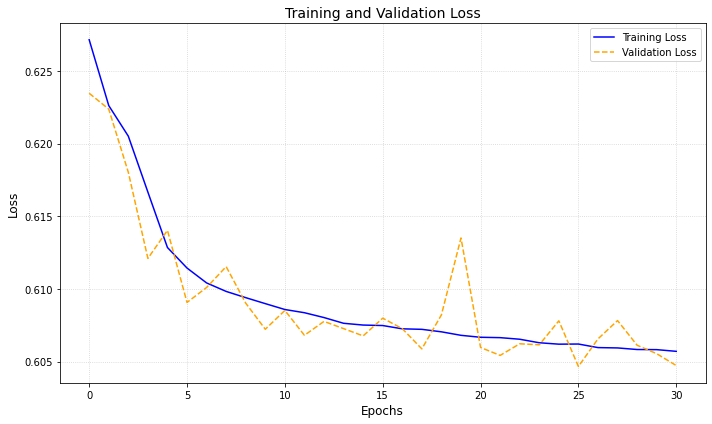

In [ ]:
print("Plot Loss Function")
model_name = "reweight"
model_path = "/home/aegis/Titan1/NRAD/data/Models"
loss_data = np.load(f"{model_path}/loss_data/{model_name}_loss.npz", allow_pickle=True)
# print(loss_data)
epochs = loss_data['epochs']
train_loss = loss_data['train_loss']
val_loss = loss_data['val_loss']

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Training Loss', color='blue', linewidth=1.5)
plt.plot(epochs, val_loss, label='Validation Loss', color='orange', linestyle='--', linewidth=1.5)

# Formatting
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Display or Save
plt.tight_layout()
# plt.savefig('loss_plot.png', dpi=300)
plt.show()

In [ ]:
# Load events 
CR_regions = ["CR_emu", "CR0L", "CR1ele", "CR1eleb", "CR1mu", "CR1mub", "CR2ele", "CR2mu"]
MC_events = {}
Data_events = {}

for region in CR_regions:
    MC_events[region] = pd.read_parquet(os.path.join(MC_train_outdir_CR, f"{region}_train.parquet"))
    Data_events[region] = pd.read_parquet(os.path.join(Data_train_outdir_CR, f"{region}_train.parquet"))

    context_var = ['ht', 'met_recalc_pt']
    # Ensure weight_phys is strictly excluded from the feature list!
    features = [col for col in Data_events[region].columns if col not in context_var and col != 'weight_phys']
    
    print("Context Variables:", context_var)
    print("Feature Variables:", features)

    n_data = len(Data_events[region])
    n_mc = len(MC_events[region])
    print(f"Reweight Model ...\n{region} has {n_data} data events, {n_mc} MC events.")

    # --- 1. PREPARE INPUT ARRAYS ---
    data_cr_train = Data_events[region][context_var + features].values
    mc_cr_train = MC_events[region][context_var + features].values

    input_x_train_CR = np.concatenate([data_cr_train, mc_cr_train], axis=0)
    
    # Data = 1, MC = 0
    data_cr_labels = np.ones(n_data).reshape(-1, 1)
    mc_cr_labels = np.zeros(n_mc).reshape(-1, 1)
    input_y_train_CR = np.concatenate([data_cr_labels, mc_cr_labels], axis=0)

    # --- 2. PREPARE THE ML WEIGHTS ---
    # Calculate global scale factor to fix the 1000x yield discrepancy
    sum_mc_weight = MC_events[region]['weight_phys'].sum()
    global_scale = n_data / sum_mc_weight
    print(f"Applying Global MC Scale Factor: {global_scale:.5f}")

    # Data weight is exactly 1. MC weight is the scaled physics weight.
    data_weights = np.ones(n_data)
    mc_weights = MC_events[region]['weight_phys'].values * global_scale
    
    input_weights_CR = np.concatenate([data_weights, mc_weights], axis=0).reshape(-1, 1)

    print("Training Data Shape:", input_x_train_CR.shape, input_y_train_CR.shape, input_weights_CR.shape)

    with open(f"{config_path}/reweight_physics.yml", 'r') as stream:
        params_rw = yaml.safe_load(stream)

    # --- 3. INITIALIZE AND TRAIN ---
    # ENABLE SCALING HERE!
    NN_rw = Classifier(
        n_inputs=(len(context_var) + len(features)), 
        layers=params_rw["layers"], 
        learning_rate=params_rw["learning_rate"], 
        device=device,
        scale_data=False
    )
    
    print("Training Reweight...")
    NN_rw.train(
        input_x=input_x_train_CR, 
        input_y=input_y_train_CR, 
        weights=input_weights_CR, 
        save_model=True, 
        batch_size=params_rw["batch_size"], 
        n_epochs=params_rw["n_epochs"], 
        model_name=f"reweight_{region}", 
        outdir=model_path
    )
    print("Training Done for Reweight Model")

Context Variables: ['ht', 'met_recalc_pt']
Feature Variables: ['mjj', 'pt_balance', 'dphi_j1_j2', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'min_dphi_jet_met']
Reweight Model ...
CR0L has 38231202 data events, 3236836 MC events.
Applying Global MC Scale Factor: 0.00141
Training Data Shape: (41468038, 10) (41468038, 1) (41468038, 1)
Training Reweight...


 10%|=         | 5/50 [31:10<4:40:36, 374.15s/it]


Training Done for Reweight Model


#### CR CWoLa

In [26]:
eval_dir = f"CWoLa_CR_ver2"
with open(f"{config_path}/bc_discrim.yml", 'r') as stream:
    params_CWoLa_CR = yaml.safe_load(stream)

In [27]:
# Load Test Events
CR_regions = ["CR0L"]
MC_events_test = {}
MC_events_weights_test = {}
Data_events_test = {}

total_mc_events = 0
total_data_events = 0
for region in CR_regions:
    MC_events_test[region] = pd.read_parquet(os.path.join(MC_test_outdir_CR, f"{region}_test.parquet"))
    Data_events_test[region] = pd.read_parquet(os.path.join(Data_test_outdir_CR, f"{region}_test.parquet"))

    MC_events_weights_test[region] = MC_events_test[region]["weight_phys"]
    context_var = ['ht', 'met_recalc_pt']
    # features = [col for col in Data_events_test[region].columns if col not in context_var]
    features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']
    # print("Context Variables:", context_var)
    # print("Feature Variables:", features)

    # print(f"Testing Reweight Model on {region}...")
    # print(f"{region} has", len(Data_events_test[region]), "data events,", len(MC_events_test[region]), "MC events.")

    data_cr_test = Data_events_test[region][context_var + features].values
    mc_cr_test = MC_events_test[region][context_var + features].values

    # print(data_cr_test.shape)
    # print(mc_cr_test.shape)
    total_mc_events += len(mc_cr_test)
    total_data_events += len(data_cr_test)
    print("="*50)
    print(f"Total weight for {region}: {MC_events_weights_test[region].sum()}")
    print(f"Total events for {region}: {len(mc_cr_test)} MC events, {len(data_cr_test)} Data events.")
    

# print("Total MC events across all CRs:", total_mc_events)
# print("Total Data events across all CRs:", total_data_events)


Total weight for CR0L: 9200601088.0
Total events for CR0L: 1078946 MC events, 12743734 Data events.


Generating stacked Data/MC plots...
mjj


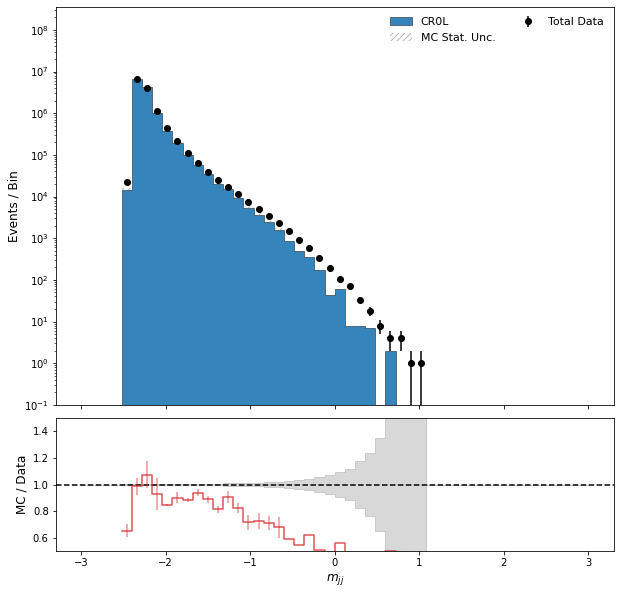

ljet1_tau21


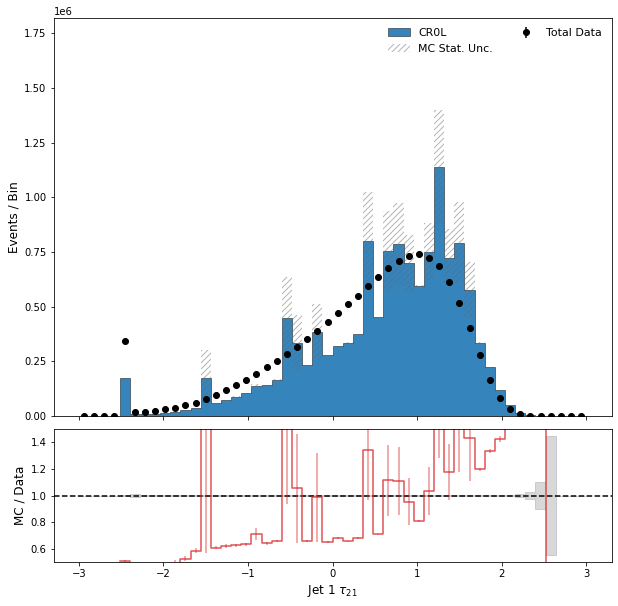

ljet1_tau32


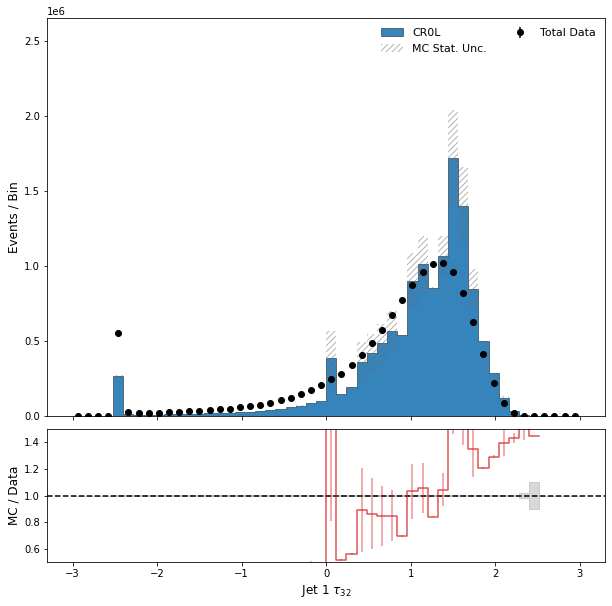

ljet2_tau21


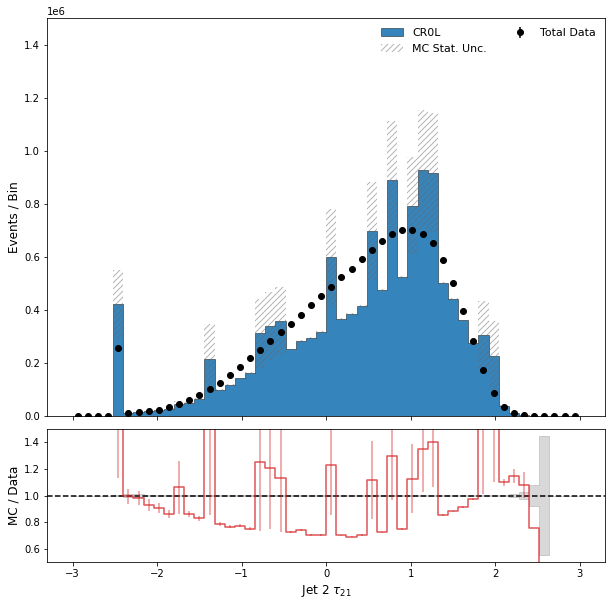

ljet2_tau32


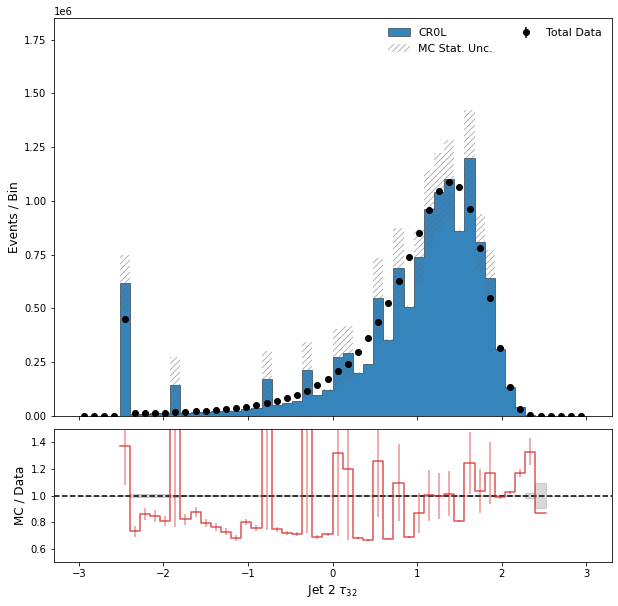

Plotting complete!


In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_stacked_crs_vs_data(
    mc_events_dict,
    data_events_dict,
    mc_weights_dict,
    regions,
    feature_names,
    log_features=None,
    save_dir=None,
    bins=50,
    val_range=(-3.0, 3.0),
    ratio_ylim=(0.5, 1.5),
    normalize_mc_to_data=True
):
    """
    Plots Total Data vs Stacked MC (split by Control Regions) with 
    a hatched MC statistical uncertainty band and ratio panel.
    """
    if log_features is None:
        log_features = []
    if save_dir and not os.path.exists(save_dir):
        os.makedirs(save_dir)

    feature_labels = {
        'mjj': r"$m_{jj}$",
        # 'pt_balance': r"$p_{\text{T}}^{\text{bal}}$",
        # 'dphi_j1_j2': r"$|\phi_{max} - \phi_{min}|$",
        'ljet1_tau21': r"Jet 1 $\tau_{21}$",
        'ljet1_tau32': r"Jet 1 $\tau_{32}$",
        'ljet2_tau21': r"Jet 2 $\tau_{21}$",
        'ljet2_tau32': r"Jet 2 $\tau_{32}$",
        # 'min_dphi_jet_met': r"$\min(\Delta\phi(E_{\text{T}}^{\text{miss}}, \text{Jet}))$"
    }

    colors = plt.cm.tab10.colors

    for feature in feature_names:
        print(feature)
        display_label = feature_labels.get(feature, feature)
        
        mc_vals_list = []
        mc_weights_list = []
        data_vals_list = []
        valid_regions = []
        
        # Gather data
        for region in regions:
            if feature in mc_events_dict[region].columns and feature in data_events_dict[region].columns:
                mc_vals_list.append(mc_events_dict[region][feature].values)
                try:
                    mc_weights_list.append(mc_weights_dict[region].values)
                except:
                    # print(f"Warning: No weights found for {region}. Using uniform weights.")
                    mc_weights_list.append(mc_weights_dict[region])
                data_vals_list.append(data_events_dict[region][feature].values)
                valid_regions.append(region)
                
        if not mc_vals_list:
            continue
            
        all_mc_vals = np.concatenate(mc_vals_list)
        all_data_vals = np.concatenate(data_vals_list)
        raw_mc_weights = np.concatenate(mc_weights_list)

        # --- YIELD NORMALIZATION ---
        if normalize_mc_to_data:
            total_data_events = len(all_data_vals)
            total_mc_weight = np.sum(raw_mc_weights)
            scale_factor = total_data_events / total_mc_weight 
            
            mc_weights_list = [w * scale_factor for w in mc_weights_list]
            all_mc_weights = raw_mc_weights * scale_factor
        else:
            all_mc_weights = raw_mc_weights
        
        # Calculate histograms
        counts_data, bin_edges = np.histogram(all_data_vals, bins=bins, range=val_range)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        err_data = np.sqrt(counts_data)
        
        counts_mc, _ = np.histogram(all_mc_vals, bins=bin_edges, weights=all_mc_weights)
        var_mc, _ = np.histogram(all_mc_vals, bins=bin_edges, weights=all_mc_weights**2)
        err_mc = np.sqrt(var_mc)

        # Plotting Setup
        fig, (ax1, ax2) = plt.subplots(
            nrows=2, ncols=1, figsize=(10, 10), 
            gridspec_kw={'height_ratios': [3, 1]}, sharex=True
        )
        plt.subplots_adjust(hspace=0.05) 

        # --- MAIN PANEL (TOP) ---
        # 1. Plot Stacked MC
        ax1.hist(
            mc_vals_list, 
            bins=bin_edges, 
            weights=mc_weights_list, 
            histtype='stepfilled', 
            stacked=True, 
            label=valid_regions,
            edgecolor='black',
            linewidth=0.5,
            alpha=0.9,
            color=colors[:len(valid_regions)]
        )
        
        # 2. Add MC Statistical Uncertainty Band (Hatched Area)
        ax1.bar(
            x=bin_centers, 
            height=2 * err_mc, 
            bottom=counts_mc - err_mc, 
            width=np.diff(bin_edges),
            fill=False, 
            hatch='////', 
            edgecolor='dimgray', 
            linewidth=0, 
            alpha=0.5, 
            label='MC Stat. Unc.', 
            zorder=4
        )

        # 3. Plot Total Data
        ax1.errorbar(bin_centers, counts_data, yerr=err_data, fmt='ko', label='Total Data', zorder=5)

        ax1.set_ylabel("Events / Bin", fontsize=12)
        ax1.legend(loc='best', frameon=False, fontsize=11, ncol=2)
        
        max_y = max(np.max(counts_data), np.max(counts_mc + err_mc))
        if feature in log_features:
            ax1.set_yscale('log')
            ax1.set_ylim(0.1, max_y * 50) 
        else:
            ax1.set_ylim(0, max_y * 1.3)

        # --- RATIO PANEL (BOTTOM) ---
        valid_mask = counts_data > 0
        safe_data = np.where(valid_mask, counts_data, 1e-10)
        rel_err_data = err_data / safe_data
        rel_err_data[~valid_mask] = 0 
        
        ax2.fill_between(
            bin_edges, 
            np.append(1 - rel_err_data, 1 - rel_err_data[-1]), 
            np.append(1 + rel_err_data, 1 + rel_err_data[-1]), 
            step='post', color='gray', alpha=0.3, label='Data Stat. Unc.', zorder=1
        )
        ax2.axhline(1.0, color='black', linestyle='--', zorder=2)
        
        ratio = counts_mc / safe_data
        ratio_err = err_mc / safe_data 
        ratio_plot = np.where(valid_mask, ratio, np.nan)
        
        ax2.step(bin_edges, np.append(ratio_plot, ratio_plot[-1]), where='post', 
                 linewidth=1.5, color='tab:red', alpha=0.8, label="MC / Data")
        ax2.errorbar(bin_centers[valid_mask], ratio_plot[valid_mask], 
                     yerr=ratio_err[valid_mask], fmt='none', ecolor='tab:red', alpha=0.5)

        ax2.set_xlabel(display_label, fontsize=12)
        ax2.set_ylabel("MC / Data", fontsize=12)
        ax2.set_ylim(ratio_ylim) 
        
        if save_dir:
            plt.savefig(os.path.join(save_dir, f"{feature}_stacked.png"), bbox_inches='tight', dpi=300)
        
        plt.show()
        plt.close()

# 1. Define the specific features you want to plot
features_list = [
    'mjj','ljet1_tau21', 'ljet1_tau32', 
    'ljet2_tau21', 'ljet2_tau32'
]

# 2. Define which features should have a logarithmic y-axis
features_to_log = [
    'mjj'
]

# 3. Call the plotting function
print("Generating stacked Data/MC plots...")

plot_stacked_crs_vs_data(
    mc_events_dict=MC_events_test,
    data_events_dict=Data_events_test,
    mc_weights_dict=MC_events_weights_test,
    regions=["CR0L"],
    feature_names=features_list,
    log_features=features_to_log,
    save_dir=f"{eval_dir}/publication_plots_stacked", # Directory to save the images
    bins=50,
    val_range=(-3.0, 3.0),      # Standardized range. Change if using raw physical values!
    ratio_ylim=(0.5, 1.5),
    normalize_mc_to_data=True   # Ensures MC total yield exactly matches Data total yield
)

print("Plotting complete!")

Model for CR0L exists at /home/aegis/Titan1/NRAD/data/Models/reweight_CR0L_FineTuned_3x500.pt
7
Model Architecture Detail:
Layer 0: Linear(in_features=7, out_features=100, bias=True)
Layer 1: ReLU()
Layer 2: Linear(in_features=100, out_features=100, bias=True)
Layer 3: ReLU()
Layer 4: Linear(in_features=100, out_features=100, bias=True)
Layer 5: ReLU()
Layer 6: Linear(in_features=100, out_features=1, bias=True)
Layer 7: Sigmoid()
Generating samples
mjj


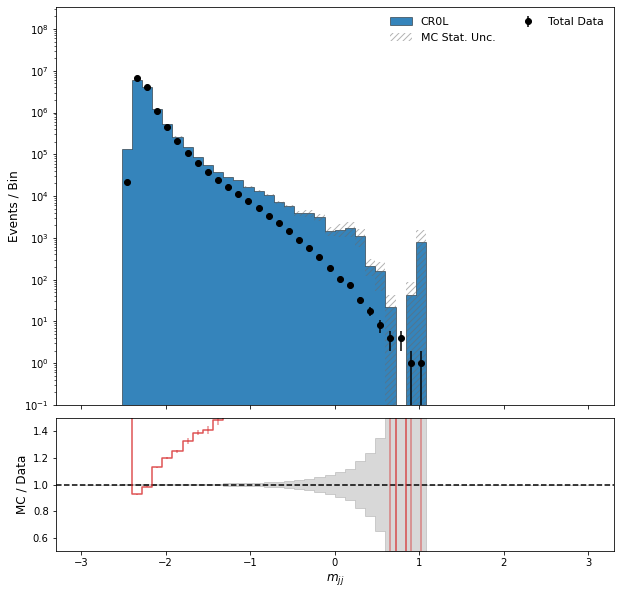

ljet1_tau21


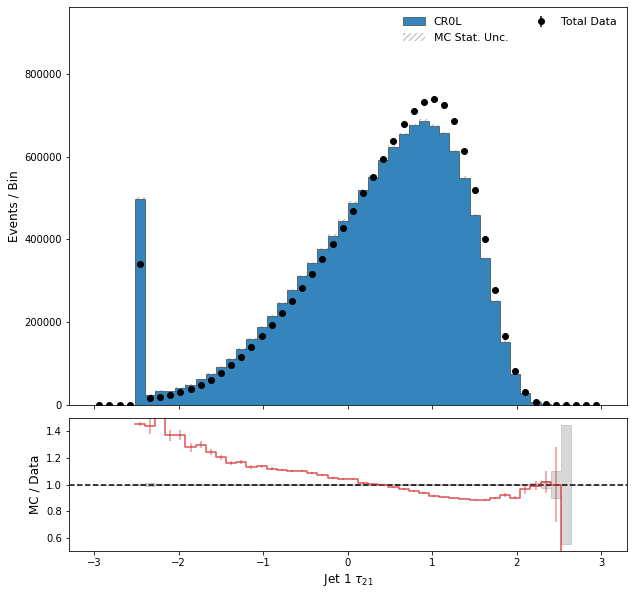

ljet1_tau32


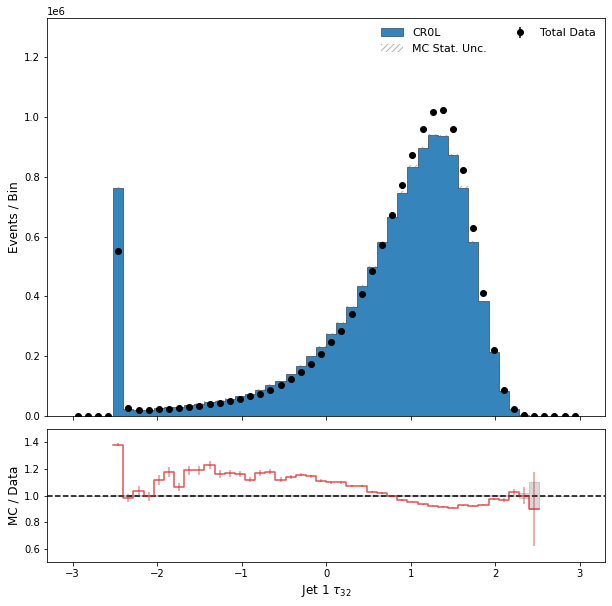

ljet2_tau21


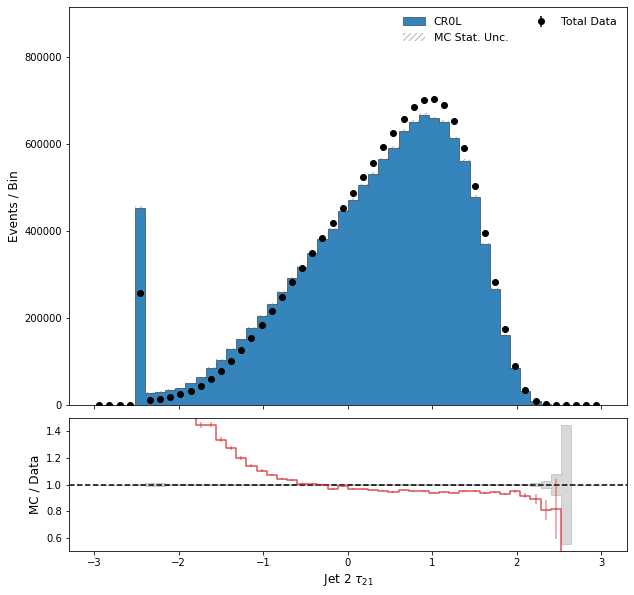

ljet2_tau32


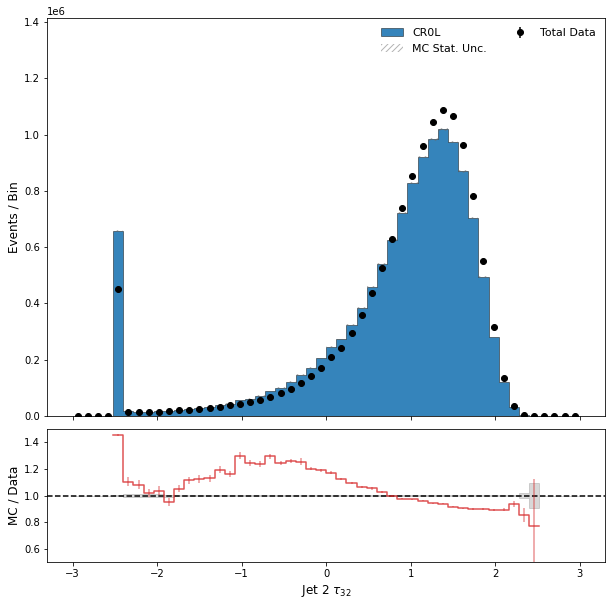

In [19]:
model = "reweight"
model_path = "/home/aegis/Titan1/NRAD/data/Models"
weights_reweight = {}

for region in ["CR0L"]:
    # model_path_region = os.path.join(model_path, f"{model}_PreTrained_3x100.pt")
    model_path_region = os.path.join(model_path, f"{model}_CR0L_FineTuned_3x500.pt")
    if os.path.exists(model_path_region):
        print(f"Model for {region} exists at {model_path_region}")
    else:
        print(f"Model for {region} is missing at {model_path_region}")

    NN_reweight = torch.load(model_path_region, weights_only=False)
    NN_reweight.to(device)
    print(NN_reweight.n_inputs)
    print("Model Architecture Detail:")
    for i, layer in enumerate(NN_reweight.model.model_stack):
        print(f"Layer {i}: {layer}")

    print("Generating samples")
    w_cr = NN_reweight.evaluation(MC_events_test[region][context_var + features].values)
    w_cr = (w_cr/(1-w_cr)).flatten()

    weights_reweight[region] = w_cr*(len(Data_events_test[region])/len(MC_events_test[region]))


plot_stacked_crs_vs_data(
    mc_events_dict=MC_events_test,
    data_events_dict=Data_events_test,
    mc_weights_dict=weights_reweight,
    regions=["CR0L"],
    feature_names=features_list,
    log_features=features_to_log,
    save_dir=f"{eval_dir}/publication_plots_stacked", # Directory to save the images
    bins=50,
    val_range=(-3.0, 3.0),      # Standardized range. Change if using raw physical values!
    ratio_ylim=(0.5, 1.5),
    normalize_mc_to_data=True   # Ensures MC total yield exactly matches Data total yield
)


#### CWoLa SR

In [20]:
# Load SR events
dataset_path = "/home/aegis/Titan1/NRAD/data"
mc_events_sr = pd.read_parquet(os.path.join(f"{dataset_path}/Scaled_Regions_with_weights", "MC_SR_test.parquet"))
data_events_sr = pd.read_parquet(os.path.join(f"{dataset_path}/Scaled_Regions", "Data_SR_test.parquet"))


context_var = ['ht', 'met_recalc_pt']
# features = [col for col in data_events_sr.columns if col not in context_var]
features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']


print("Context Variables:", context_var)
print("Feature Variables:", features)

print(mc_events_sr.shape)
print(data_events_sr.shape)
# print(mc_events_sr)

Context Variables: ['ht', 'met_recalc_pt']
Feature Variables: ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']
(38813, 11)
(76255, 10)


['CR0L']
Calculating reweighting weights from CR0L for SR...
Model for CR0L exists at /home/aegis/Titan1/NRAD/data/Models/reweight_CR0L_FineTuned_3x500.pt
7
Generating samples
Plotting combined SR distributions...
mjj


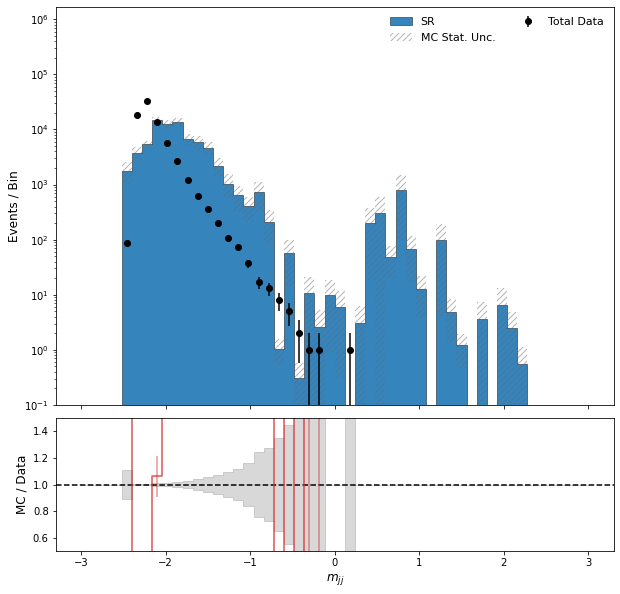

ljet1_tau21


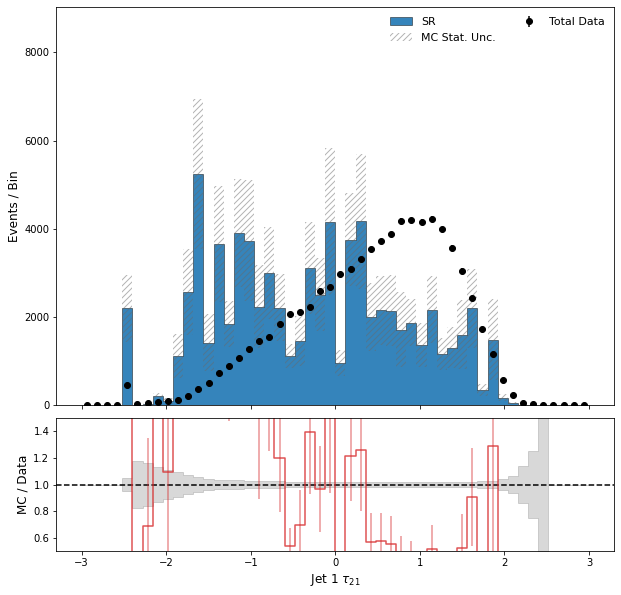

ljet1_tau32


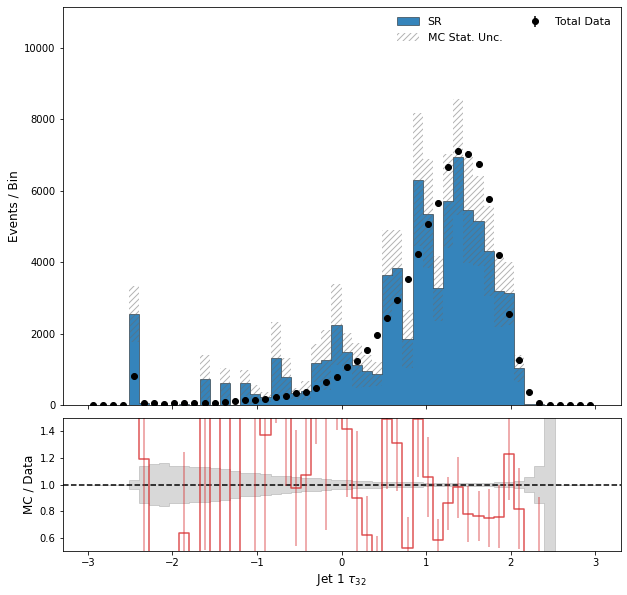

ljet2_tau21


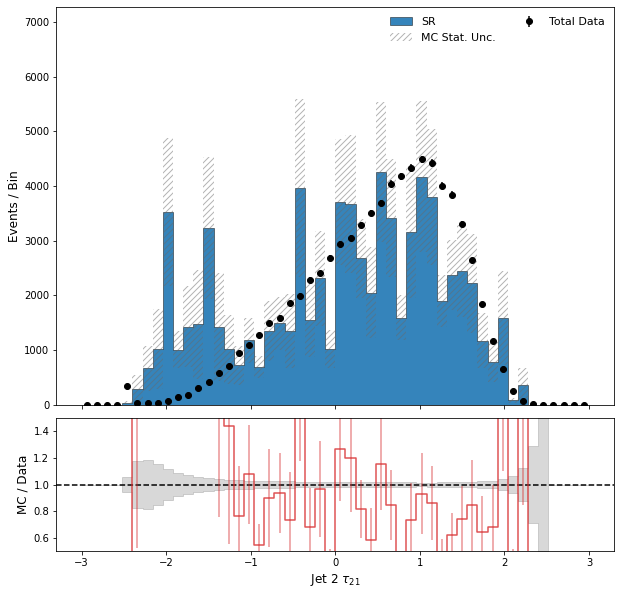

ljet2_tau32


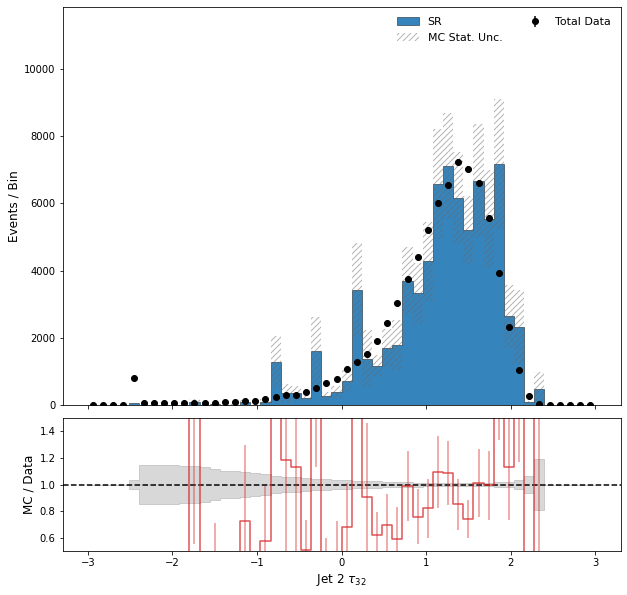

In [25]:
import numpy as np
model_path = "/home/aegis/Titan1/NRAD/data/Models"
# 1. Initialize an array of zeros with the same length as your SR MC events
combined_w_sr = np.zeros(len(mc_events_sr))


def regularize_weights(w_arr, sigma = 3.0):
    w_copy = np.copy(w_arr)
    mean_w = np.mean(w_copy)
    std_w = np.std(w_copy)
    w_copy[w_copy > (sigma*std_w + mean_w)] = 0
    return w_copy

print(CR_regions)
for region in ["CR0L"]:
    print(f"Calculating reweighting weights from {region} for SR...")
    # model_path_region = os.path.join(model_path, f"{model}_PreTrained_3x100.pt")
    model_path_region = os.path.join(model_path, f"{model}_CR0L_FineTuned_3x500.pt")
    if os.path.exists(model_path_region):
        print(f"Model for {region} exists at {model_path_region}")
    else:
        print(f"Model for {region} is missing at {model_path_region}")

    NN_reweight = torch.load(model_path_region, weights_only=False)
    NN_reweight.to(device)
    print(NN_reweight.n_inputs)

    print("Generating samples")
    
    w_sr = NN_reweight.evaluation(mc_events_sr[context_var + features].values)
    w_sr = np.clip(w_sr, 1e-7, 1.0 - 1e-7)
    w_sr = (w_sr / (1 - w_sr)).flatten()

    w_sr = regularize_weights(w_sr, sigma=3.0)
    # 2. Add this region's predicted weights to the total combined weights
    # w_sr = np.ones(len(w_sr))
    combined_w_sr += w_sr

# print(combined_w_sr)
# 3. Plot exactly once outside the loop using the accumulated weights
print("Plotting combined SR distributions...")
plot_stacked_crs_vs_data(
    mc_events_dict={"SR": mc_events_sr},
    data_events_dict={"SR": data_events_sr},
    mc_weights_dict={"SR": combined_w_sr},
    regions=["SR"],
    feature_names=features_list,
    log_features=features_to_log,
    save_dir=f"{eval_dir}/publication_plots_SR_combined", # Updated directory name
    bins=50,
    val_range=(-3.0, 3.0),
    ratio_ylim=(0.5, 1.5),
    # normalize_mc_to_data=True  # Uncommented or adjusted based on your yield normalization needs
)

Plotting combined SR distributions...
mjj


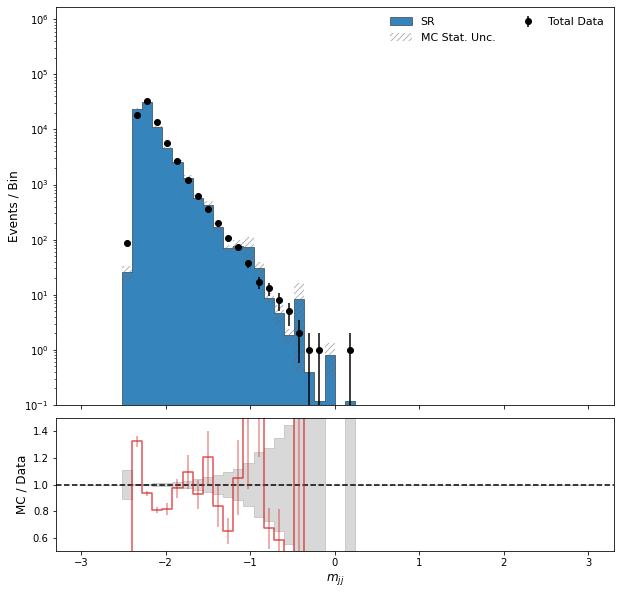

pt_balance


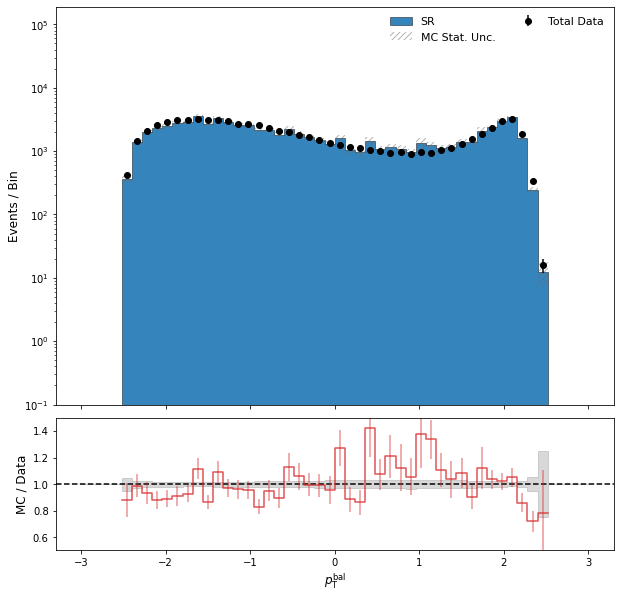

ljet1_tau21


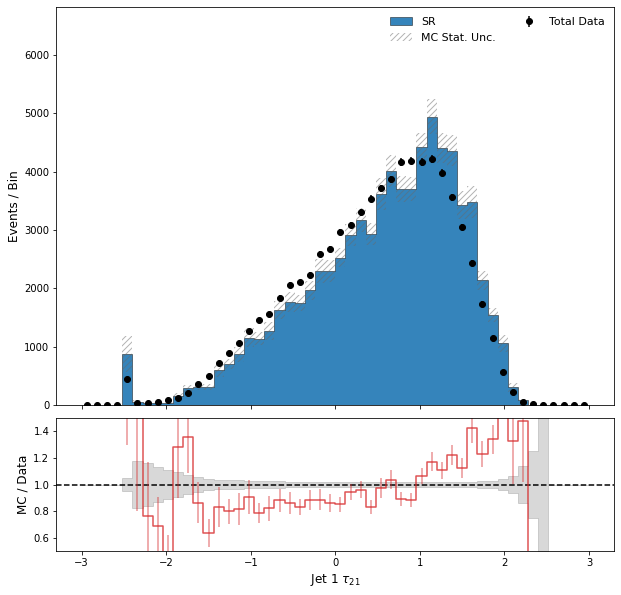

ljet1_tau32


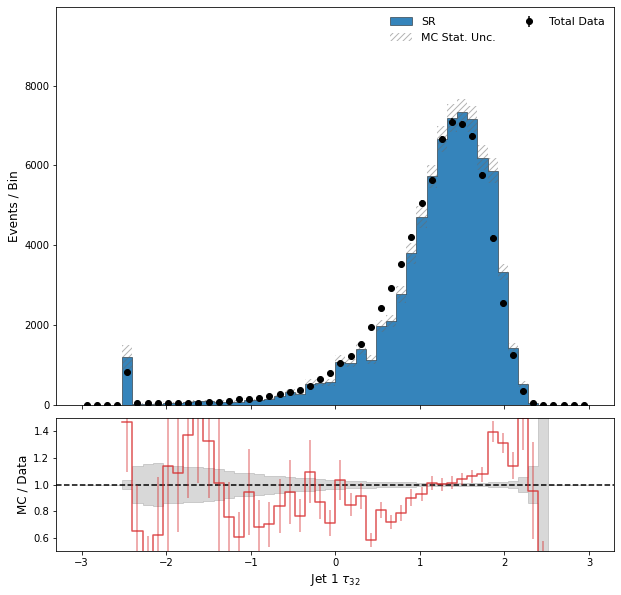

ljet2_tau21


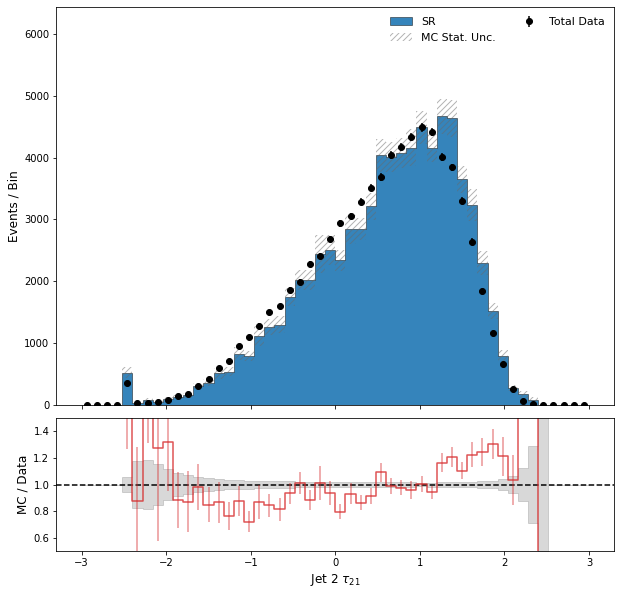

ljet2_tau32


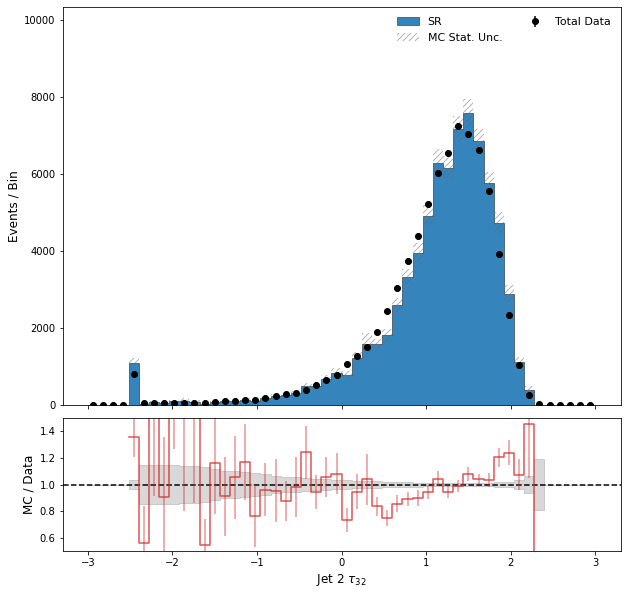

dphi_j1_j2


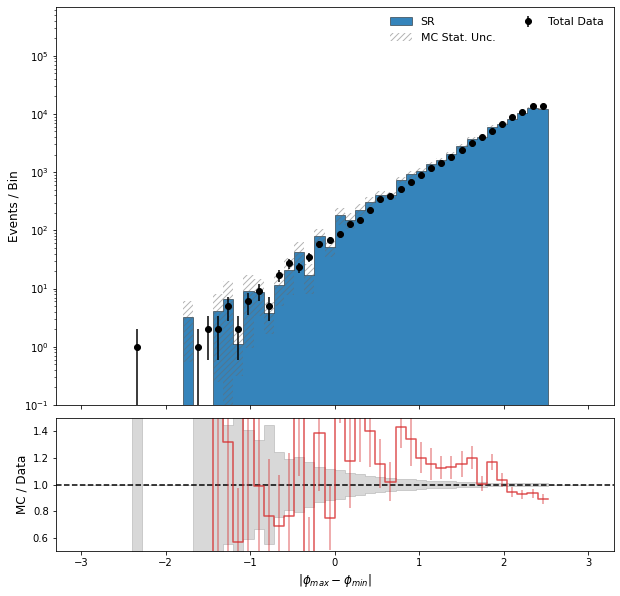

min_dphi_jet_met


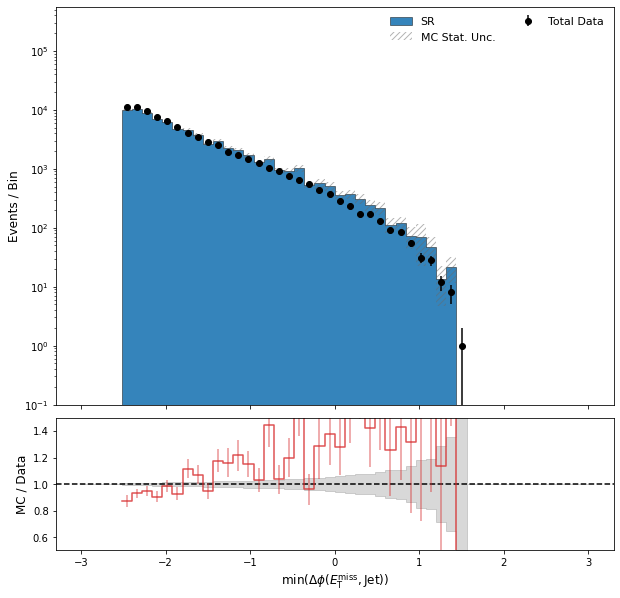

In [ ]:
# 3. Plot exactly once outside the loop using the accumulated weights
print("Plotting combined SR distributions...")
plot_stacked_crs_vs_data(
    mc_events_dict={"SR": mc_events_sr},
    data_events_dict={"SR": data_events_sr},
    mc_weights_dict={"SR": mc_events_sr["weight_phys"]},  # Apply combined reweighting to original MC weights
    regions=["SR"],
    feature_names=features_list,
    log_features=features_to_log,
    save_dir=f"{eval_dir}/publication_plots_SR_combined", # Updated directory name
    bins=50,
    val_range=(-3.0, 3.0),
    ratio_ylim=(0.5, 1.5),
    # normalize_mc_to_data=True  # Uncommented or adjusted based on your yield normalization needs
)

### Generate

In [ ]:
import numpy as np
import pandas as pd
import os
import yaml

CR_regions = ["CR_emu", "CR0L", "CR1ele", "CR1eleb", "CR1mu", "CR1mub", "CR2ele", "CR2mu"]
Data_events = {}

context_var = ['ht', 'met_recalc_pt']
features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

# Lists to hold data for Phase 1 (All Regions)
all_features = []
all_context = []

# Variables to hold data for Phase 2 (CR0L only)
cr0l_features_train = None
cr0l_context_train = None

print("--- LOADING AND PREPARING DATA ---")
for region in CR_regions:
    # Notice: No MC_events loaded! Generate only models the Data.
    Data_events[region] = pd.read_parquet(os.path.join(Data_train_outdir_CR, f"{region}_train.parquet"))
    
    data_features = Data_events[region][features].values
    data_context = Data_events[region][context_var].values
    
    # Append to our "All Regions" lists
    all_features.append(data_features)
    all_context.append(data_context)

    # Isolate CR0L for fine-tuning later
    if region == "CR0L":
        cr0l_features_train = data_features
        cr0l_context_train = data_context

# Combine all regions into massive Phase 1 arrays
input_features_ALL = np.concatenate(all_features, axis=0)
input_context_ALL = np.concatenate(all_context, axis=0)

# Load hyperparameters
with open(f"{config_path}/generate_physics.yml", 'r') as stream:
    params = yaml.safe_load(stream)

# --- PHASE 1: PRE-TRAINING (The "General Education") ---
print("\n--- PHASE 1: Pre-training Normalizing Flow on ALL Control Regions ---")
print(f"Combined Training Data Shape: {input_features_ALL.shape}")

# Initialize the MAF model ONCE
MAF = SimpleMAF(
    num_features=len(features), 
    num_context=len(context_var), 
    device=device, 
    num_layers=params["n_layers"], 
    num_hidden_features=params["n_hidden_features"], 
    learning_rate=params["learning_rate"]
)

# Train on the combined dataset
MAF.train(
    data=input_features_ALL, 
    cond=input_context_ALL, 
    batch_size=params["batch_size"], 
    n_epochs=params["n_epochs"], 
    outdir=model_path, 
    save_model=True, # Wait to save until fine-tuning is done
    model_name="generate_PreTrained"
)

# --- PHASE 2: FINE-TUNING (The "Specialization" for CR0L) ---
print("\n--- PHASE 2: Fine-Tuning Normalizing Flow exclusively on CR0L ---")

# Lower the learning rate so we don't scramble the learned representations
fine_tune_lr = params["learning_rate"] / 10.0
# Assuming SimpleMAF stores its PyTorch optimizer as self.optimizer
for param_group in MAF.optimizer.param_groups:
    param_group['lr'] = fine_tune_lr
print(f"Reduced learning rate to {fine_tune_lr}")

# Resume training on ONLY the CR0L arrays
MAF.train(
    data=cr0l_features_train, 
    cond=cr0l_context_train, 
    batch_size=params["batch_size"], 
    n_epochs=params["n_epochs"] // 2, # Often requires fewer epochs for fine-tuning
    outdir=model_path, 
    save_model=True, 
    model_name="generate_CR0L_FineTuned"
)

print("\nDone training! The Normalizing Flow is now specialized for the 0L background.")

--- LOADING AND PREPARING DATA ---

--- PHASE 1: Pre-training Normalizing Flow on ALL Control Regions ---
Combined Training Data Shape: (39595626, 5)


 20%|==        | 4/20 [3:01:10<12:05:40, 2721.26s/it]

--- EVALUATING GENERATE METHOD FOR CR0L ---
Loaded MAF model from /home/aegis/Titan1/NRAD/data/Models/generate_PreTrained.pt
Generating synthetic samples from MC context...


Generation: 100%|██████████| 108/108 [00:01<00:00, 68.86it/s]
/tmp/ipykernel_290463/3305686712.py:64: RuntimeWarning: divide by zero encountered in divide
  w_cr = (w_prob / (1.0 - w_prob)).flatten()
/home/aegis/.local/lib/python3.10/site-packages/numpy/_core/_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Loaded Reweight model for w(m) from /home/aegis/Titan1/NRAD/data/Models/reweight_CR0L_FineTuned_3x500.pt
Calculating likelihood ratio weights...
Weights clipped at nan (Mean: inf, Std: nan)
Calculated weights for CR0L with mean 1.0000 and std 0.0000

Plotting Generate method results...
mjj


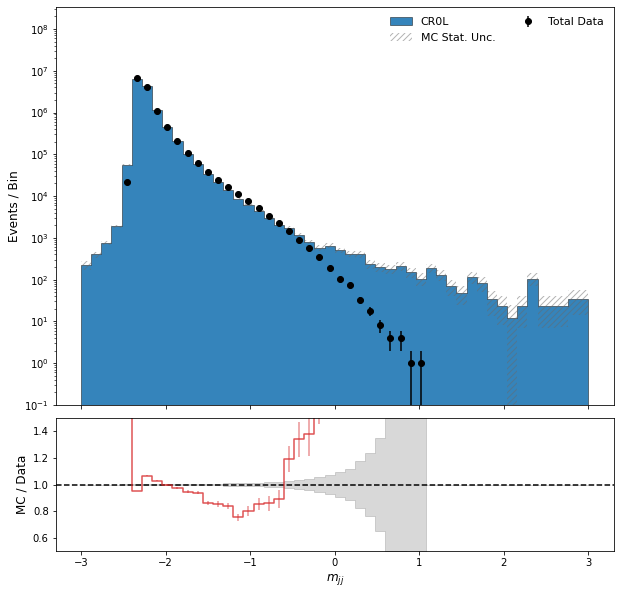

ljet1_tau21


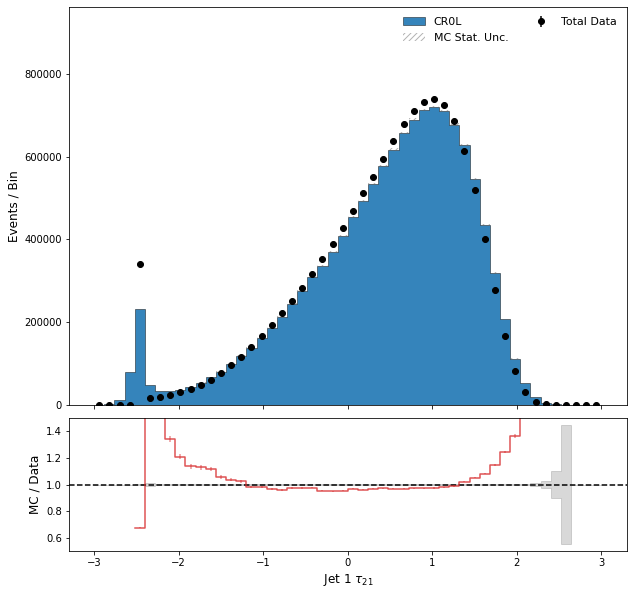

ljet1_tau32


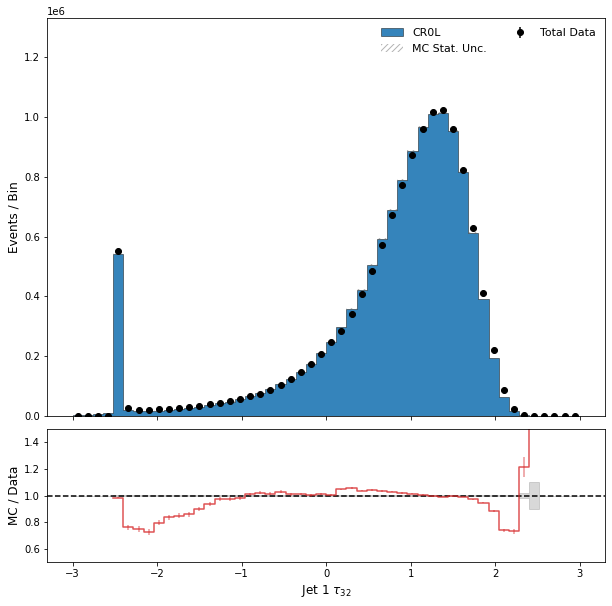

ljet2_tau21


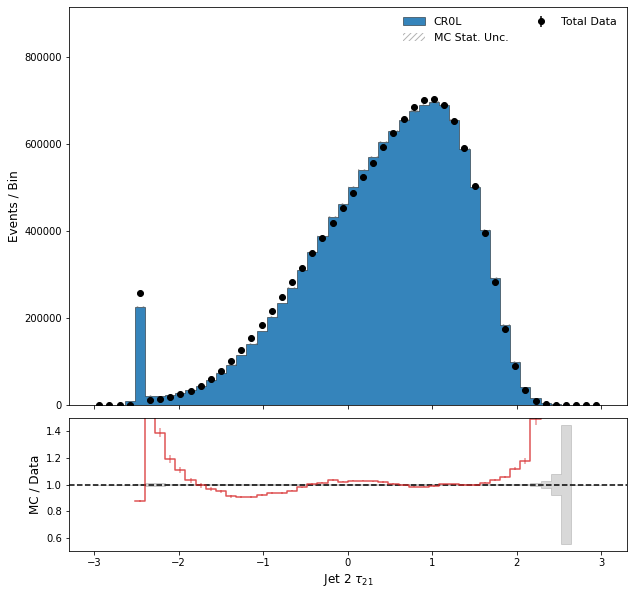

ljet2_tau32


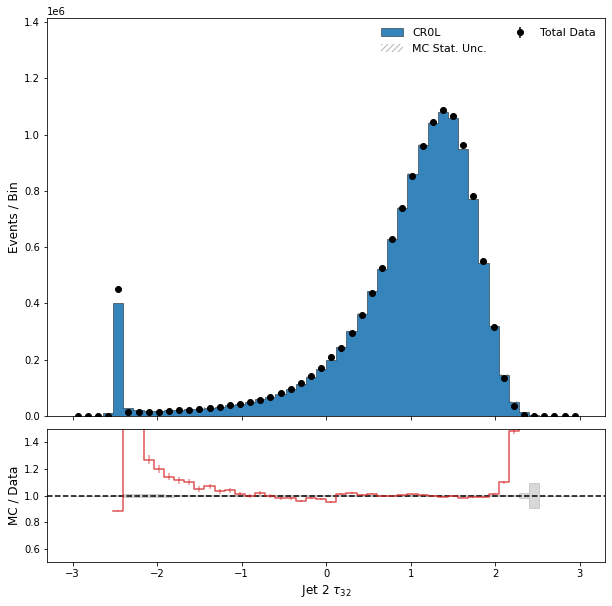

Done!


In [32]:
import torch
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

model_path = "/home/aegis/Titan1/NRAD/data/Models"
region = "CR0L"
context_var = ['ht', 'met_recalc_pt']
features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

# Dictionaries to hold the synthetic data and calculated weights for plotting
Synthetic_events_test = {}
weights_generate = {}

print(f"--- EVALUATING GENERATE METHOD FOR {region} ---")

# 1. Load the fine-tuned Generative Model (MAF)
maf_model_path = os.path.join(model_path, "generate_PreTrained.pt")
MAF = torch.load(maf_model_path, map_location=device, weights_only=False)
MAF.flow.eval()
print(f"Loaded MAF model from {maf_model_path}")

# 2. Extract MC context to drive the generation
mc_df = MC_events_test[region]
mc_context = mc_df[context_var].values

# 3. Generate Synthetic Features in batches (to avoid VRAM limits)
batch_size = 10000
generated_features_list = []

print("Generating synthetic samples from MC context...")
with torch.inference_mode():
    for i in tqdm(range(0, len(mc_context), batch_size), desc="Generation"):
        cond_batch = mc_context[i:i + batch_size]
        # sample() returns the generated features
        gen_feats = MAF.sample(num_samples=1, cond=cond_batch)
        generated_features_list.append(gen_feats)

synthetic_features = np.concatenate(generated_features_list, axis=0)

# Create a temporary dataframe for the synthetic events
synthetic_df = pd.DataFrame(synthetic_features, columns=features)
for i, col in enumerate(context_var):
    synthetic_df[col] = mc_context[:, i]

# Store it in our dictionary for the plotter
Synthetic_events_test[region] = synthetic_df

# 4. Load the fine-tuned Reweight model to calculate w(m)
rw_model_path = os.path.join(model_path, "reweight_CR0L_FineTuned_3x500.pt")
NN_reweight = torch.load(rw_model_path, map_location=device, weights_only=False)
NN_reweight.to(device)
# If it has a standard PyTorch module stack, ensure eval mode:
if hasattr(NN_reweight, 'model'):
    NN_reweight.model.eval() 
print(f"Loaded Reweight model for w(m) from {rw_model_path}")

# 5. Calculate weights using the GENERATED features + context
input_for_weights = synthetic_df[context_var + features].values

print("Calculating likelihood ratio weights...")
w_prob = NN_reweight.evaluation(input_for_weights)
w_cr = (w_prob / (1.0 - w_prob)).flatten()

# 6. Apply 3-sigma clipping (Crucial for stability per the paper)
mean_w = np.mean(w_cr)
std_w = np.std(w_cr)
cutoff = mean_w + (3 * std_w)
w_cr_clipped = np.clip(w_cr, a_min=0, a_max=cutoff)
print(f"Weights clipped at {cutoff:.4f} (Mean: {mean_w:.4f}, Std: {std_w:.4f})")

# Calculate final plotting weights matching your global scale logic
weights_generate[region] = w_cr_clipped * (len(Data_events_test[region]) / len(MC_events_test[region]))
weights_generate[region] = np.ones_like(weights_generate[region])  # For testing, use uniform weights to isolate generation effects
print(f"Calculated weights for {region} with mean {weights_generate[region].mean():.4f} and std {weights_generate[region].std():.4f}")
# 7. Plotting directly
print("\nPlotting Generate method results...")
plot_stacked_crs_vs_data(
    mc_events_dict=Synthetic_events_test,  # Notice we pass SYNTHETIC events, not raw MC
    data_events_dict=Data_events_test,
    mc_weights_dict=weights_generate,      # Pass the calculated w(m) weights
    regions=["CR0L"],
    feature_names=features_list,
    log_features=features_to_log,
    save_dir=f"{eval_dir}/publication_plots_stacked_generate", # Save to a separate folder
    bins=50,
    val_range=(-3.0, 3.0),
    ratio_ylim=(0.5, 1.5),
    # normalize_mc_to_data=True
)
print("Done!")